In [2]:
import pvlib
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import datetime 
import pytz
import pandas as pd
import numpy as np
import requests
import math

# Ввод местоположения объекта

In [3]:
lat = 47.99
long = 139.53
time_zone = 'Asia/Vladivostok'
loc = pvlib.location.Location(lat, long, time_zone)

# Ввод промежутка времени



In [4]:
start_time = datetime.datetime(2023, 1, 1, 0)
end_time = datetime.datetime(2023, 12, 31, 23)
model_freq = '1h'

date_array = pd.date_range(start = start_time,
                           end = end_time,
                           freq = model_freq,
                           tz = time_zone) 


# Функция сдвига времени

In [5]:
def time_change(data_source, date_array):
    
    delta_time_full = date_array[1].strftime('%z')
    delta_time = int(delta_time_full[0 : 3])

    lendata = len(data_source)

    if delta_time >= 0:
        date_transfer_end = data_source[lendata - delta_time : lendata]
        date_transfer_main = data_source[0 : lendata - delta_time]
        data_changed = pd.concat([date_transfer_end, date_transfer_main], ignore_index = True)
    elif delta_time < 0:
        date_transfer_start = data_source[0 : abs(delta_time)]
        date_transfer_main = data_source[abs(delta_time) : lendata]
        data_changed = pd.concat([date_transfer_main, date_transfer_end], ignore_index = True)
    
    data_changed['time'] = date_array
    data_changed = data_changed.set_index('time')

    return(data_changed)

# Положение солнца (год)

In [6]:
SPA_obj = pvlib.solarposition.spa_python(date_array,
                                         loc.latitude,
                                         loc.longitude,
                                         loc.altitude)


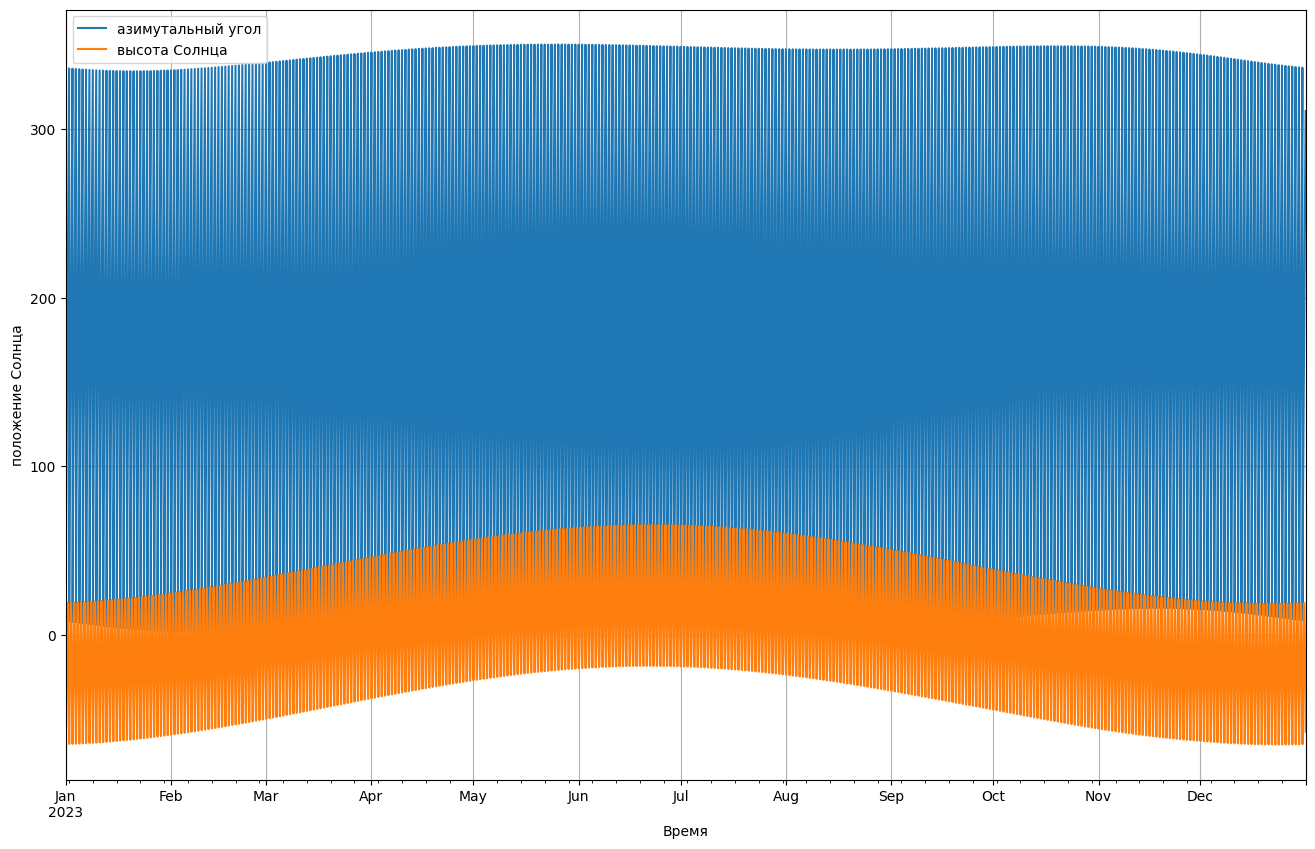

In [7]:
SPA_obj['azimuth'].plot(label = 'азимутальный угол', figsize = (16,10))
SPA_obj['elevation'].plot(label = 'высота Солнца')
plt.legend()
plt.xlabel('Время')
plt.ylabel('положение Солнца') 
plt.grid()
plt.show()

# SPA - характерные дни

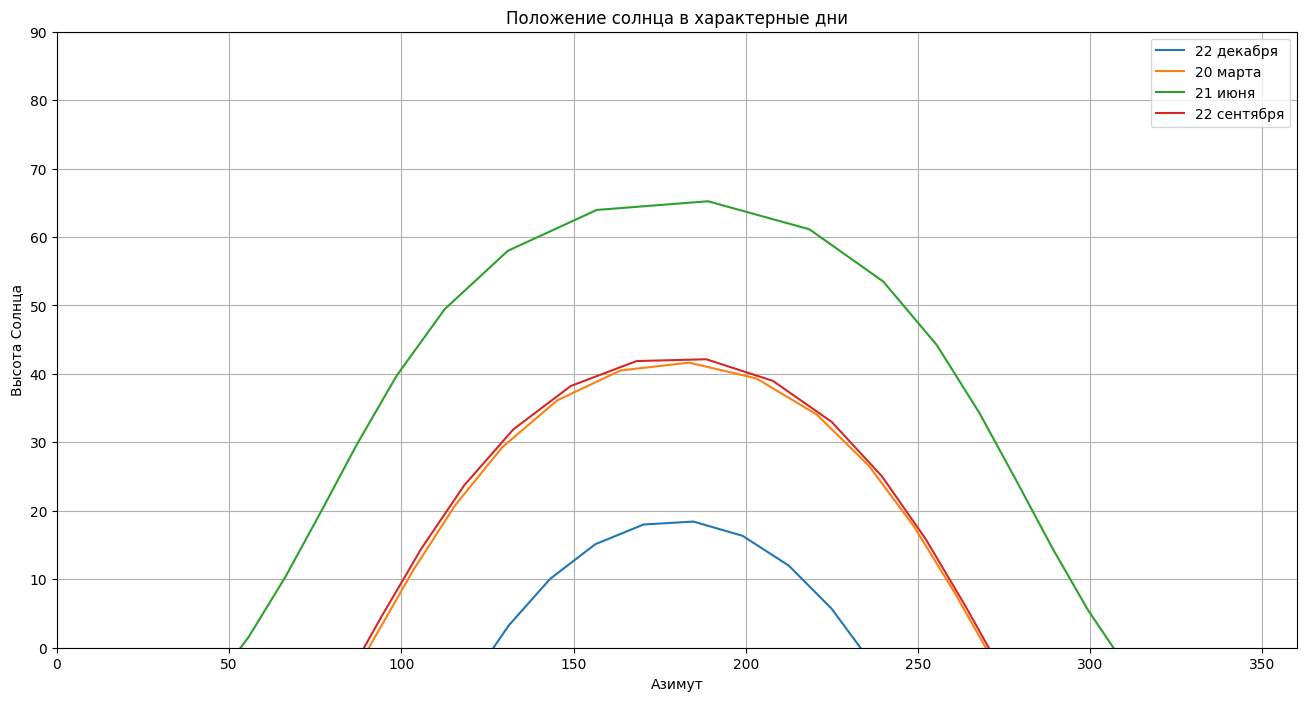

<Figure size 1600x800 with 0 Axes>

In [8]:
DOY_winter = 356
SPA_winter = SPA_obj.iloc[(DOY_winter - 1) * 24 : DOY_winter * 24]

DOY_spring = 79
SPA_spring = SPA_obj.iloc[(DOY_spring - 1) * 24 : DOY_spring * 24]

DOY_summer = 172
SPA_summer = SPA_obj.iloc[(DOY_summer - 1) * 24 : DOY_summer * 24]

DOY_autumn = 265
SPA_autumn = SPA_obj.iloc[(DOY_autumn - 1) * 24 : DOY_autumn * 24]

plt.figure(figsize = (16,8))
plt.plot(SPA_winter['azimuth'],SPA_winter['elevation'], label = '22 декабря')
plt.plot(SPA_spring['azimuth'],SPA_spring['elevation'], label = '20 марта')
plt.plot(SPA_summer['azimuth'],SPA_summer['elevation'], label = '21 июня')
plt.plot(SPA_autumn['azimuth'],SPA_autumn['elevation'], label = '22 сентября')
plt.xlabel('Азимут')
plt.ylabel('Высота Солнца') 
plt.grid(10)
plt.ylim(0,90)
plt.xlim(0,360)
plt.legend()
plt.title('Положение солнца в характерные дни')
plt.figure(figsize = (16,8))
plt.show()

# Заатмосферное СИ

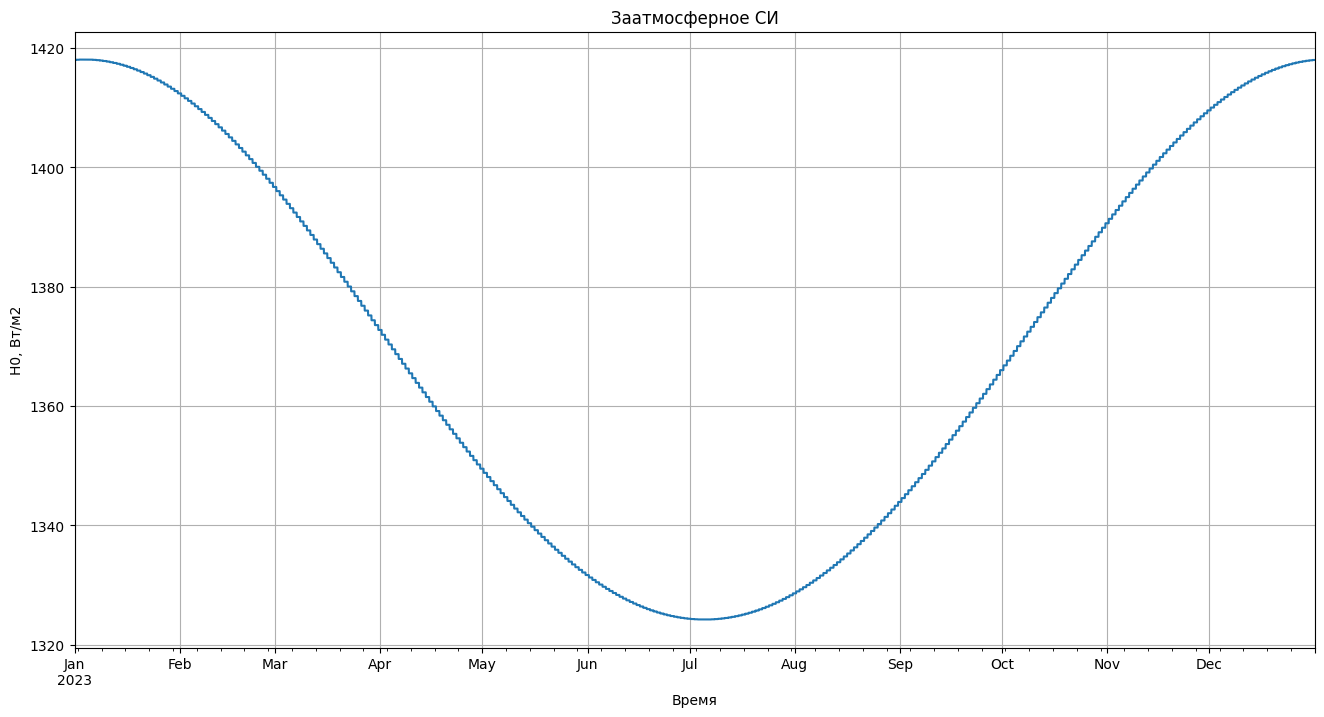

In [9]:
DNI_extra = pvlib.irradiance.get_extra_radiation(date_array,1370,'spencer')
DNI_extra.plot(figsize = (16,8))
plt.xlabel('Время')
plt.ylabel('H0, Вт/м2') 
plt.grid()
plt.title('Заатмосферное СИ')
plt.show()

# Простая модель чистого неба

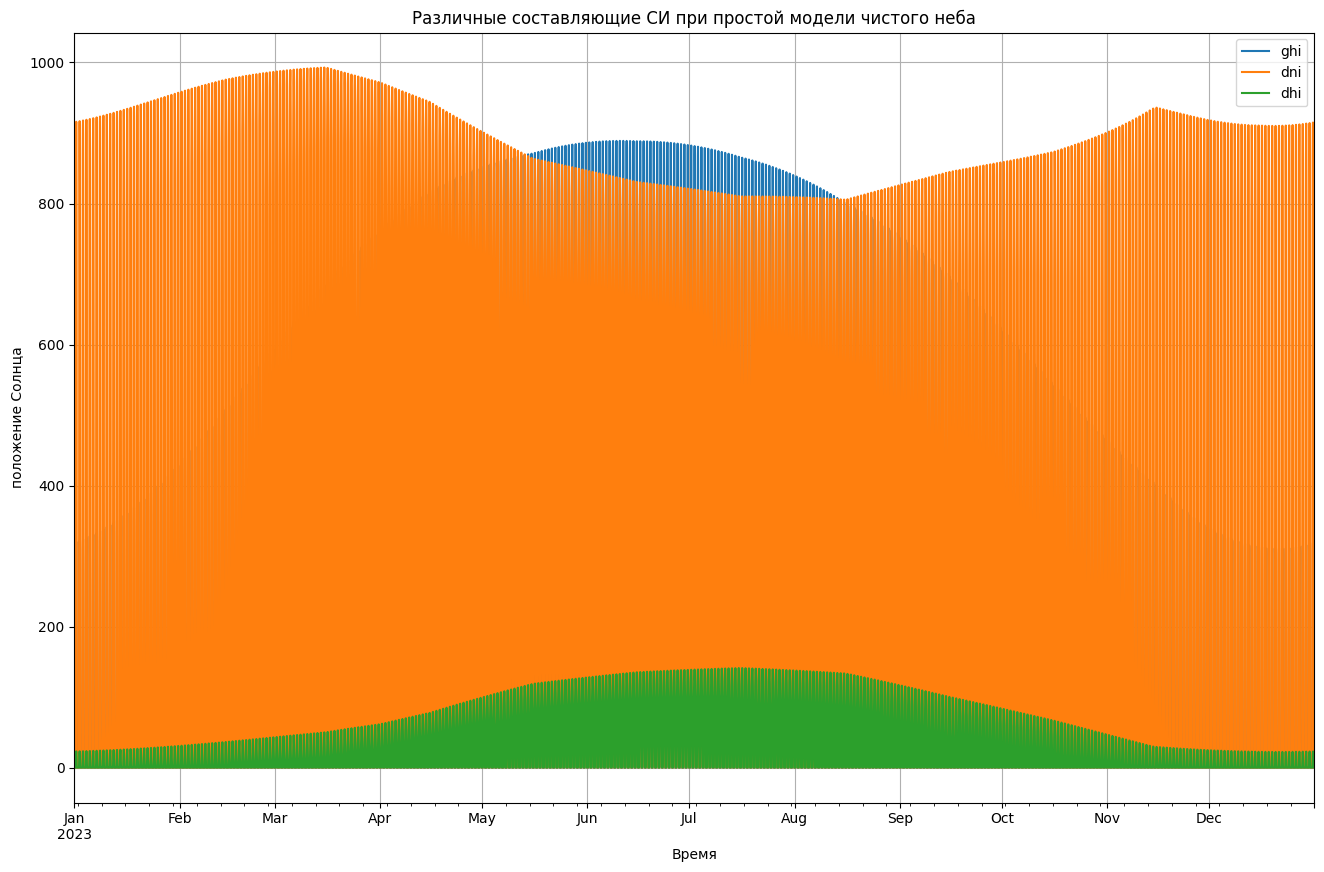

In [10]:
rel_airmass_obj = pvlib.atmosphere.get_relative_airmass(zenith = SPA_obj['zenith'],
                                                       model = 'kastenyoung1989')
                                 
abs_airmass_obj = pvlib.atmosphere.get_absolute_airmass(airmass_relative = rel_airmass_obj,
                                                        pressure = 99725.13)

linke_turbidity_obj = pvlib.clearsky.lookup_linke_turbidity(date_array,
                                                            loc.latitude,
                                                            loc.longitude,
                                                           )

simple_clear_sky_source = pvlib.clearsky.ineichen(SPA_obj['apparent_zenith'],
                        airmass_absolute = abs_airmass_obj ,
                        linke_turbidity = linke_turbidity_obj,
                        altitude = loc.altitude ,
                        dni_extra = DNI_extra,
                        perez_enhancement = False)

simple_clear_sky_source.plot(figsize = (16,10))
plt.xlabel('Время')
plt.ylabel('положение Солнца') 
plt.grid()
plt.title('Различные составляющие СИ при простой модели чистого неба')
plt.show()


# Смещение времени в датафрейме SimpleClearSky

In [11]:

#

simple_clear_sky = time_change(simple_clear_sky_source, date_array)

# Получение данных с PVGIS и добавление столбца GHI

In [12]:
year_PVGIS = int(start_time.year)

PVGIS_data_source, PVGIS_input_source, PVGIS_metadata_source = pvlib.iotools.get_pvgis_hourly(latitude = loc.latitude,
                               longitude = loc.longitude,
                               start = year_PVGIS,
                               end = year_PVGIS,
                               raddatabase = None ,
                               components = True,
                               surface_tilt = 0,
                               surface_azimuth = 180 ,
                               outputformat = 'csv',
                               usehorizon = True,
                               userhorizon = None,
                               pvcalculation = False,
                               peakpower = None,
                               pvtechchoice = 'crystSi',
                               mountingplace = 'free',
                               loss = 0,
                               trackingtype = 0,
                               optimal_surface_tilt = False,
                               optimalangles = False,
                               url = 'https://re.jrc.ec.europa.eu/api/',
                               map_variables = True,
                               timeout = 30)

PVGIS_data_source['ghi'] = PVGIS_data_source['poa_sky_diffuse'] + PVGIS_data_source['poa_direct']


# Смещение времени в датафрейме PVGIS

In [13]:
start_time = datetime.datetime(year_PVGIS, 1, 1, 0)
end_time = datetime.datetime(year_PVGIS, 12, 31, 23)
model_freq = '1h'

date_array_PVGIS = pd.date_range(start = start_time,
                           end = end_time,
                           freq = model_freq,
                           tz = time_zone) 

delta_time_full = date_array[1].strftime('%z')
delta_time = int(delta_time_full[0 : 3])

lendata = len(PVGIS_data_source)

if delta_time >= 0:
    date_transfer_end = PVGIS_data_source[lendata - delta_time : lendata]
    date_transfer_main =  PVGIS_data_source[0 : lendata - delta_time]
    PVGIS_data = pd.concat([date_transfer_end, date_transfer_main], ignore_index = True)
elif delta_time < 0:
    date_transfer_start = PVGIS_data_source[0 : abs(delta_time)]
    date_transfer_main = PVGIS_data_source[abs(delta_time) : lendata]
    PVGIS_data = pd.concat([date_transfer_main, date_transfer_end], ignore_index = True)
    
PVGIS_data['time'] = date_array_PVGIS
PVGIS_data = PVGIS_data.set_index('time')

# Добавление столбца DNI в PVGIS

In [14]:
PVGIS_data['dni'] = pvlib.irradiance.disc(ghi = PVGIS_data['ghi'],
                      solar_zenith = SPA_obj['zenith'],
                      datetime_or_doy = PVGIS_data.index)['dni']

# Поиск дня в году (PVGIS)

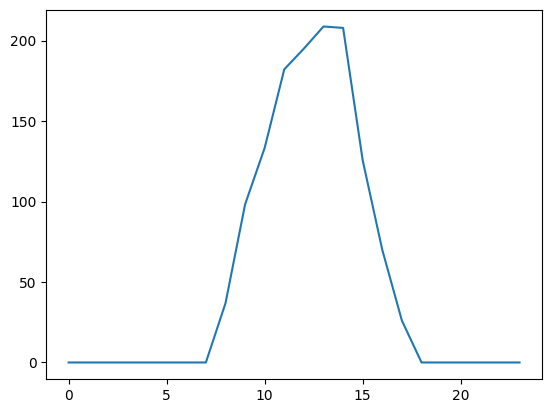

In [15]:
DOY = 50
GHI_day = PVGIS_data.iloc[(DOY - 1) * 24: DOY * 24, [1]]
TIME_day = range(24)
plt.plot(TIME_day, GHI_day)
plt.show()

# Получение значений суммарного СИ из СБД NASA


In [16]:
# задаём начальную и конечную даты периода, за которых хотим получить данные
start_nasa = start_time.strftime('%Y%m%d')
stop_nasa = end_time.strftime('%Y%m%d')

# Из раздела документации Parameter Dictionary выбраны следующие параметры:
# ALLSKY_SRF_ALB        # The all sky rate of reflectivity of the earth's surface; the ratio of the solar energy reflected by the surface of the earth compared to the total solar energy incident reaching the surface of the earth.
# ALLSKY_SFC_SW_DIFF    # The diffuse (light energy scattered out of the direction of the sun) solar irradiance incident on a horizontal plane at the surface of the earth under all sky conditions.
# ALLSKY_SFC_SW_DNI     # The direct solar irradiance incident to a horizontal plane normal (perpendicular) to the direction of the sun's position under all sky conditions.
# ALLSKY_SFC_SW_DWN     # The total solar irradiance incident (direct plus diffuse) on a horizontal plane at the surface of the earth under all sky conditions. An alternative term for the total solar irradiance is the "Global Horizontal Irradiance" or GHI.
# T2M                   # The average air (dry bulb) temperature at 2 meters above the surface of the earth.
# WS10M                 # The average of wind speed at 10 meters above the surface of the earth.

# Оригинальная строка запроса:
#base_url = r"https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M,T2MDEW,T2MWET,TS,T2M_RANGE,T2M_MAX,T2M_MIN&community=RE&longitude={longitude}&latitude={latitude}&start=20150101&end=20150305&format=JSON"
# Заменим указанные параметры на нужные нам, а также даты начала-конца периода на переменные start и stop
base_url = r"https://power.larc.nasa.gov/api/temporal/hourly/point?parameters=ALLSKY_SRF_ALB,ALLSKY_SFC_SW_DIFF,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DWN,T2M,WS10M&community=RE&longitude={longitude}&latitude={latitude}&start={start}&end={stop}&format=CSV"

# Функция Python format() - это встроенная строковая функция, используемая для форматирования строк.
api_request_url = base_url.format(longitude = loc.longitude,
                                  latitude = loc.latitude,
                                  start = start_nasa, 
                                  stop = stop_nasa)

# С помощью функции requests.get обратимся по заданному url за данными
response = requests.get(url=api_request_url, verify=True, timeout=30.00)

# преобразуем данные в строку
content = str(response.content)

# заменим последовательность символов '\n' на перевод строки по всему тексту (maxsplit=-1)
content = content.split(sep=r'\n', maxsplit=-1)

# Придумаем название файлу, в который сохраним данные
NASAfilename = 'NASA_SSE_date__lat' + str(loc.latitude) + '_lon' + str(loc.longitude) + '.csv'

# Откроем файл с нужным именем в режиме "для записи"
f = open(NASAfilename, 'w')

# Запишем в файл каждую строку из переменной content, добавив в конце перевод строки
for text in content:
    f.write(text + '\n')

    # Закроем файл, чтобы с ним можно было и дальше работать
f.close()

# Прочитаем файл в dataframe, пропустив первые строки, в которых идёт описание данных 
# (предварительно файл надо открыть и количество этих строе подсчитать)
NASA_data_source = pd.read_csv(NASAfilename, sep = ',', skiprows = 14, header = 0)

# Удалим последнюю "пустую" строку
NASA_data_source = NASA_data_source.drop(index = 8760)


# Преобразвование NASA_data к единому формату по времени

In [17]:
time_array_nasa = []
NASA_data = NASA_data_source
for i in range(lendata):
    time_array_nasa.append(datetime.datetime(int(NASA_data.iloc[i, 0]),
                                         int(NASA_data.iloc[i, 1]),
                                         int(NASA_data.iloc[i, 2]),
                                         int(NASA_data.iloc[i, 3])))
    time_array_nasa[i] = pytz.timezone(time_zone).localize(time_array_nasa[i])


NASA_data['time'] = time_array_nasa
NASA_data = NASA_data.set_index('time')
NASA_data = NASA_data.drop(columns = ['YEAR', 'MO', 'DY', 'HR'])

# Получение месячных сумм суммарного СИ PVGIS, SimpleClearSky (SCS) и NASA

              PVGIS  SimpleClearSky       NASA
Январь     52.71721       59.441418   54.62113
Февраль    80.70744       87.118673   79.80671
Март      117.87534      150.580883  107.01475
Апрель    145.69882      194.891792  132.45293
Май       182.78040      233.363470  158.52514
Июнь      171.89106      237.842701  149.75034
Июль      150.05745      234.302428  136.94625
Август    118.83934      202.004168  119.73205
Сентябрь  128.66716      153.580594  130.67132
Октябрь    86.04757      109.411291   89.42479
Ноябрь     46.64908       67.288724   45.42344
Декабрь    39.76074       49.787426   42.36291


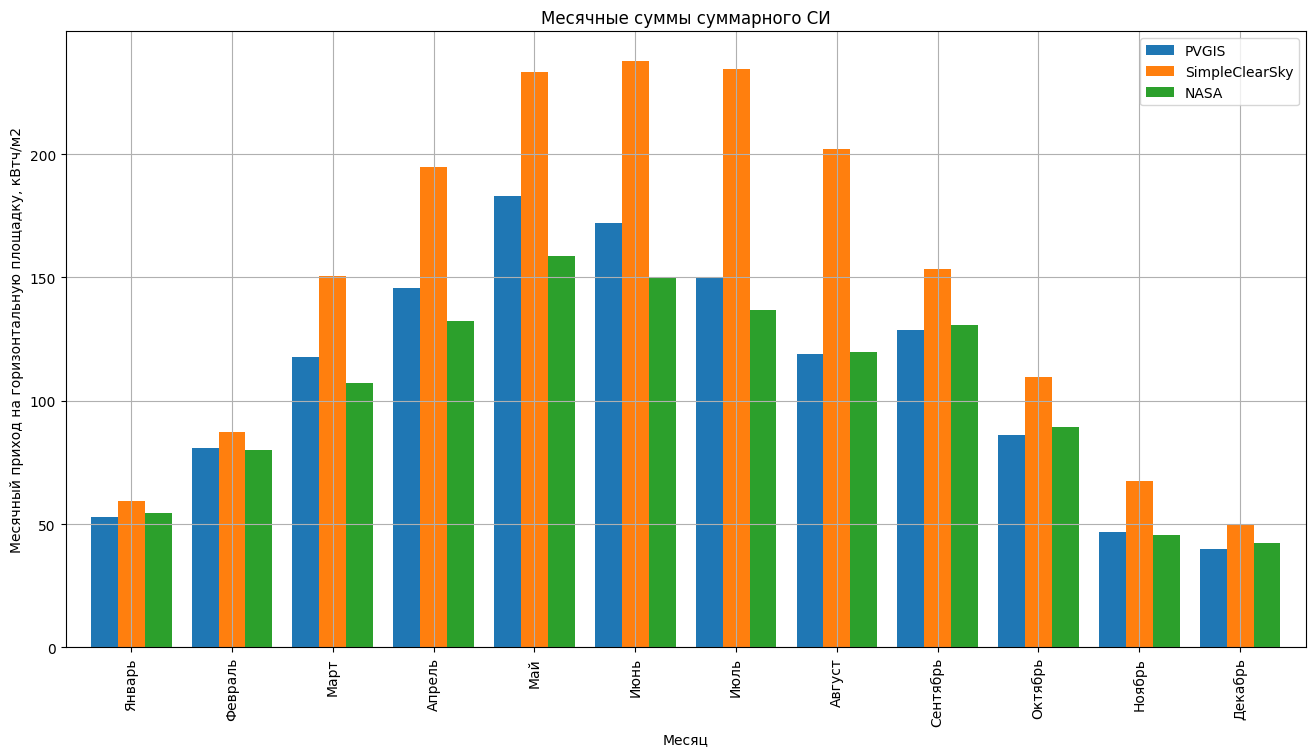

In [18]:
GHI_month_sum_PVGIS = [0.0] * 12
GHI_month_sum_SCS = [0.0] * 12
GHI_month_sum_NASA = [0.0] * 12

months_array = ['Январь','Февраль','Март','Апрель','Май','Июнь','Июль','Август','Сентябрь','Октябрь','Ноябрь','Декабрь']

for i in range (lendata):
    month = int(PVGIS_data.index[i].to_pydatetime().strftime('%m'))
    GHI_month_sum_PVGIS[month - 1] += float(PVGIS_data.iloc[i , 7] / 1000)
    GHI_month_sum_SCS[month - 1] += float(simple_clear_sky.iloc[i, 0] / 1000)
    GHI_month_sum_NASA[month - 1] += float(NASA_data.iloc[i, 3] / 1000)

pd_transf_GHI = {'PVGIS': GHI_month_sum_PVGIS,
            'SimpleClearSky': GHI_month_sum_SCS,
            'NASA': GHI_month_sum_NASA}
pd_month_GHI = pd.DataFrame(pd_transf_GHI, index = months_array)
print(pd_month_GHI)

pd_month_GHI.plot(kind = 'bar', figsize = (16,8), width = 0.8)
plt.xlabel('Месяц')
plt.ylabel('Месячный приход на горизонтальную площадку, кВтч/м2') 
plt.grid()
plt.title('Месячные суммы суммарного СИ')
plt.show()    

 
    
    

# Годовые суммы приходов суммарногоСИ

In [19]:
GHI_year_PVGIS = sum(pd_month_GHI['PVGIS'])
GHI_year_SCS = sum(pd_month_GHI['SimpleClearSky'])
GHI_year_NASA = sum(pd_month_GHI['NASA'])

print('PVGIS ----', GHI_year_PVGIS)
print('SCS ----', GHI_year_SCS)
print('NASA ----', GHI_year_NASA)

PVGIS ---- 1321.6916099999996
SCS ---- 1779.613566577008
NASA ---- 1246.7317600000006


# Получение месячных сумм диффузного СИ PVGIS, SimpleClearSky (SCS) и NASA

             PVGIS  SimpleClearSky      NASA
Январь    19.19277        4.483440  24.88032
Февраль   25.97494        6.418050  33.88712
Март      38.40771       11.982830  51.58656
Апрель    52.77781       22.649707  65.50880
Май       60.37346       38.326817  77.02668
Июнь      72.10820       44.596874  75.18890
Июль      66.55930       46.945763  76.39164
Август    52.82896       40.619610  60.38743
Сентябрь  42.49838       27.190523  49.01711
Октябрь   27.30214       15.977276  35.12719
Ноябрь    19.08854        6.123757  26.22218
Декабрь   16.14773        3.859535  21.94032


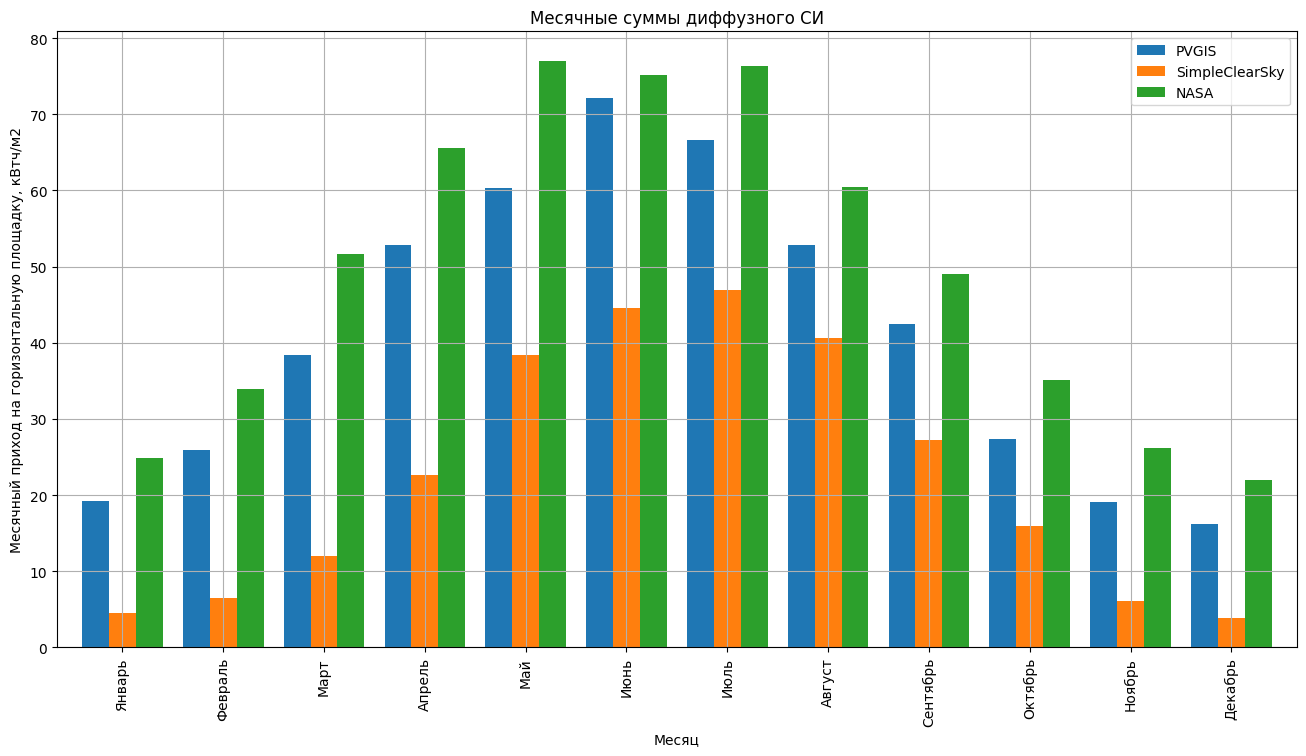

In [20]:
DHI_month_sum_PVGIS = [0.0] * 12
DHI_month_sum_SCS = [0.0] * 12
DHI_month_sum_NASA = [0.0] * 12

months_array = ['Январь','Февраль','Март','Апрель','Май','Июнь','Июль','Август','Сентябрь','Октябрь','Ноябрь','Декабрь']

for i in range (lendata):
    month = int(PVGIS_data.index[i].to_pydatetime().strftime('%m'))
    DHI_month_sum_PVGIS[month - 1] += float(PVGIS_data.iloc[i , 1] / 1000)
    DHI_month_sum_SCS[month - 1] += float(simple_clear_sky.iloc[i, 2] / 1000)
    DHI_month_sum_NASA[month - 1] += float(NASA_data.iloc[i, 1] / 1000)

pd_transf = {'PVGIS': DHI_month_sum_PVGIS,
            'SimpleClearSky': DHI_month_sum_SCS,
            'NASA': DHI_month_sum_NASA}
pd_month_DHI = pd.DataFrame(pd_transf, index = months_array)
print(pd_month_DHI)

pd_month_DHI.plot(kind = 'bar', figsize = (16,8), width = 0.8)
plt.xlabel('Месяц')
plt.ylabel('Месячный приход на горизонтальную площадку, кВтч/м2') 
plt.grid()
plt.title('Месячные суммы диффузного СИ')
plt.show()    

 
    
    

# Годовые суммы приходов диффузной сотавляющей СИ

In [21]:
DHI_year_PVGIS = sum(pd_month_DHI['PVGIS'])
DHI_year_SCS = sum(pd_month_DHI['SimpleClearSky'])
DHI_year_NASA = sum(pd_month_DHI['NASA'])

print('PVGIS ----', DHI_year_PVGIS)
print('SCS ----', DHI_year_SCS)
print('NASA ----', DHI_year_NASA)

PVGIS ---- 493.2599399999999
SCS ---- 269.17418192112206
NASA ---- 597.1642500000002


# Сравнение данных PVGIS и расчета по методу Агнстрема

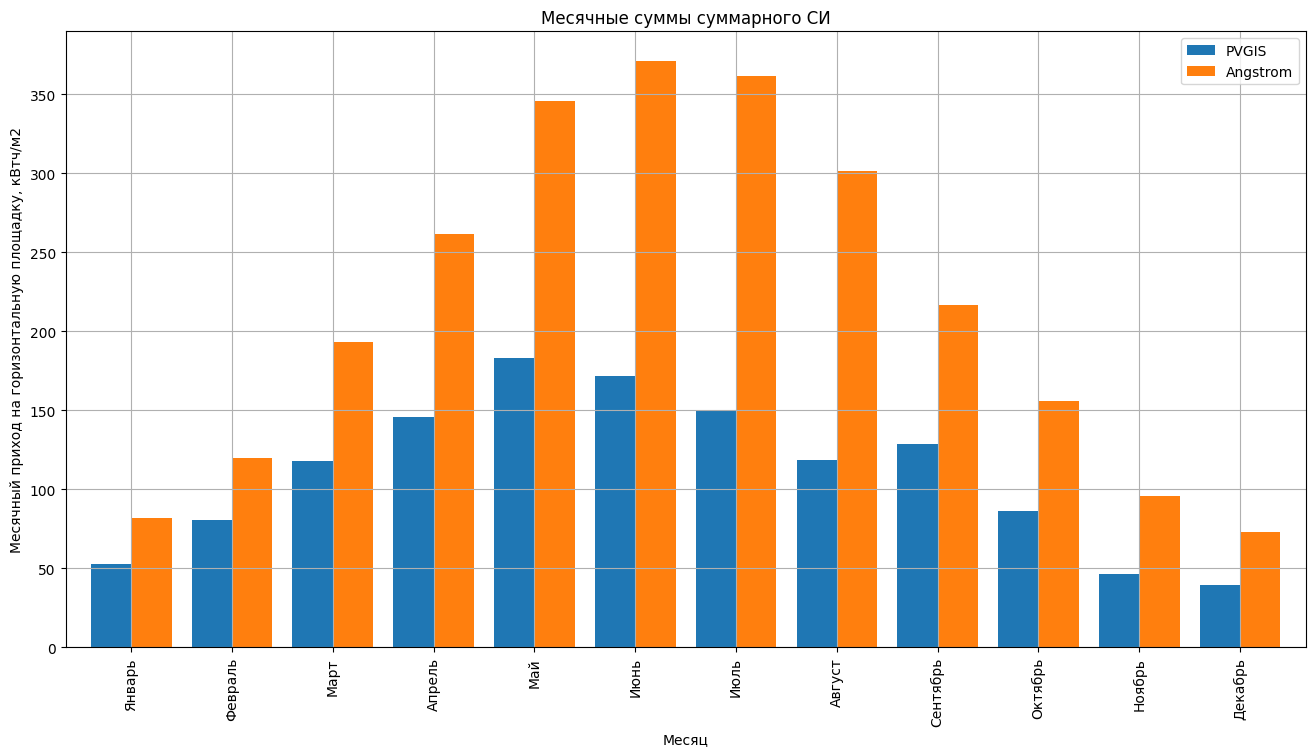

In [22]:
GHI_month_sum_Angstrem = [82.1, 120.1, 193.2,
                          261.4, 346.0, 371.2,
                          361.4, 301.7, 216.5,
                          155.6, 95.5, 72.8] 

pd_month_GHI['Angstrom'] = GHI_month_sum_Angstrem

pd_month_GHI.iloc[0 : len(pd_month_GHI), [0, 3]].plot(kind = 'bar', figsize = (16,8), width = 0.8)
plt.xlabel('Месяц')
plt.ylabel('Месячный приход на горизонтальную площадку, кВтч/м2') 
plt.grid()
plt.title('Месячные суммы суммарного СИ')
plt.show()    

 

#plt.figure(figsize = (16,8))
#plt.bar(months_array, pd_month_GHI['Angstrom'], label = 'метод Ангстрема')
#plt.bar(months_array, pd_month_GHI['PVGIS'], label = 'PVGIS')
#plt.xlabel('Месяц')
#lt.ylabel('Месячный приход на горизонтальную площадку, кВтч/м2') 
#plt.grid()
#plt.legend()
#plt.title('Месячные суммы суммарного СИ')
#plt.show()  



# Функция для создания датафрейма

In [23]:
def create_df (columns, values, indexes):
    pd_transf = {}
    
    for i in range(len(columns)):
        pd_transf[str(columns[i])] = values[i]
    
    df = pd.DataFrame(pd_transf, index = indexes)
    df.fillna(0, inplace = True)

    return(df)

# СИ на наклонную поверхность
# Диффузное излучение (анизотропная модель)

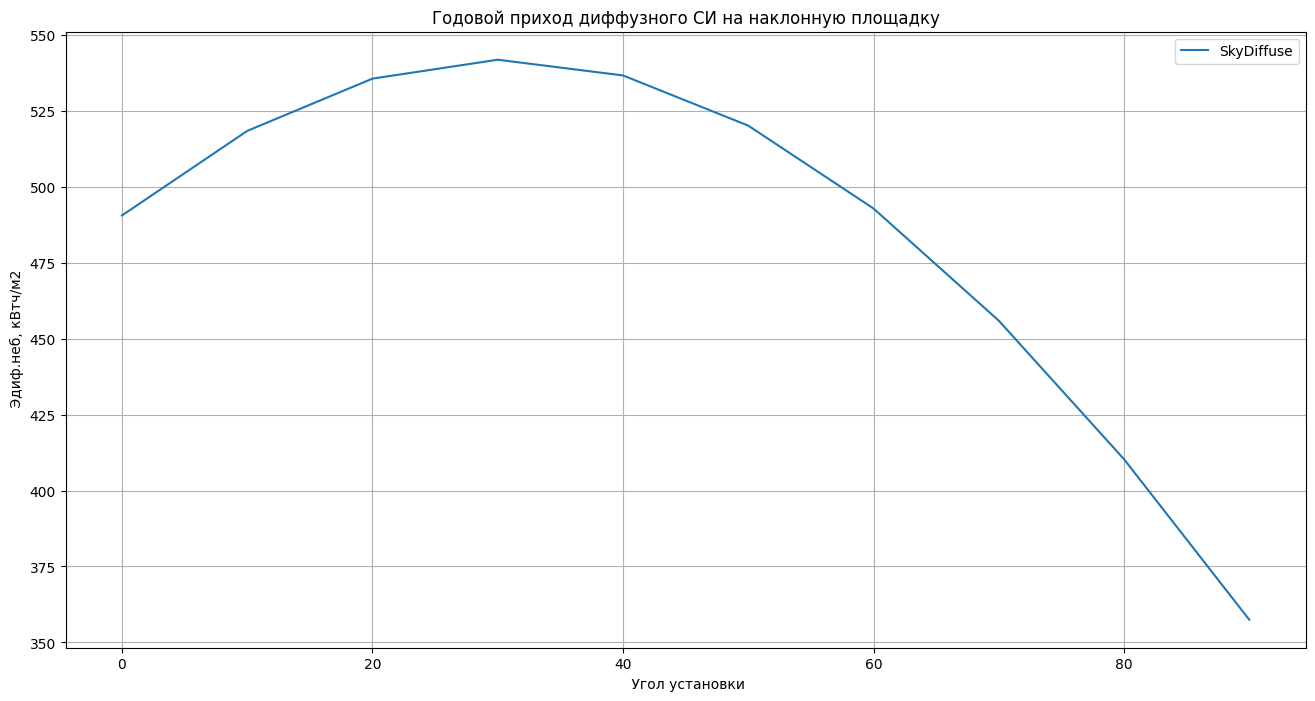

In [24]:
surface_azimuth = 180
Tilts = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
Tilt_range = len(Tilts)
DiffuseSky_Perez = [0.0] * Tilt_range

for i in range (Tilt_range):
    DiffuseSky_Perez[i] = pvlib.irradiance.perez(surface_tilt = Tilts[i],
                                                 surface_azimuth = surface_azimuth,
                                                 dhi = PVGIS_data['poa_sky_diffuse'],
                                                 dni = PVGIS_data['dni'],
                                                 dni_extra = DNI_extra,
                                                 solar_zenith = SPA_obj['apparent_zenith'],
                                                 solar_azimuth = SPA_obj['azimuth'],
                                                 airmass = rel_airmass_obj,
                                                 model = 'allsitescomposite1990',
                                                 return_components = False)

Perez_diffuse_sky_data = create_df(Tilts, DiffuseSky_Perez, PVGIS_data.index)




Sky_diff_year_sum = [0] * Tilt_range
for i in range(Tilt_range):
    Sky_diff_year_sum[i] = sum(Perez_diffuse_sky_data[str(Tilts[i])]) / 1000

Perez_year_data = pd.DataFrame(index = Tilts)
Perez_year_data['SkyDiffuse'] = Sky_diff_year_sum

Perez_year_data['SkyDiffuse'].plot(figsize = (16,8))
plt.grid()
plt.ylabel(' Эдиф.неб, кВтч/м2')
plt.xlabel(' Угол установки')
plt.legend()
plt.title('Годовой приход диффузного СИ на наклонную площадку')
plt.show()

             

# Альбедо из справочника НПС 2004 и добавление столбца Albedo в PVGIS_data

In [25]:
Albedo_month = [0.51, 0.61, 0.57, 0.34, 0.16, 0.17, 0.18, 0.19, 0.20, 0.35, 0.54, 0.34]
Albedo_hour = [0] * lendata

for i in range (lendata):
    month = int(PVGIS_data.index[i].to_pydatetime().strftime('%m'))
    Albedo_hour[i] = Albedo_month[month - 1]

PVGIS_data['Albedo'] = Albedo_hour

    

# Отраженная составляющая диффузного СИ

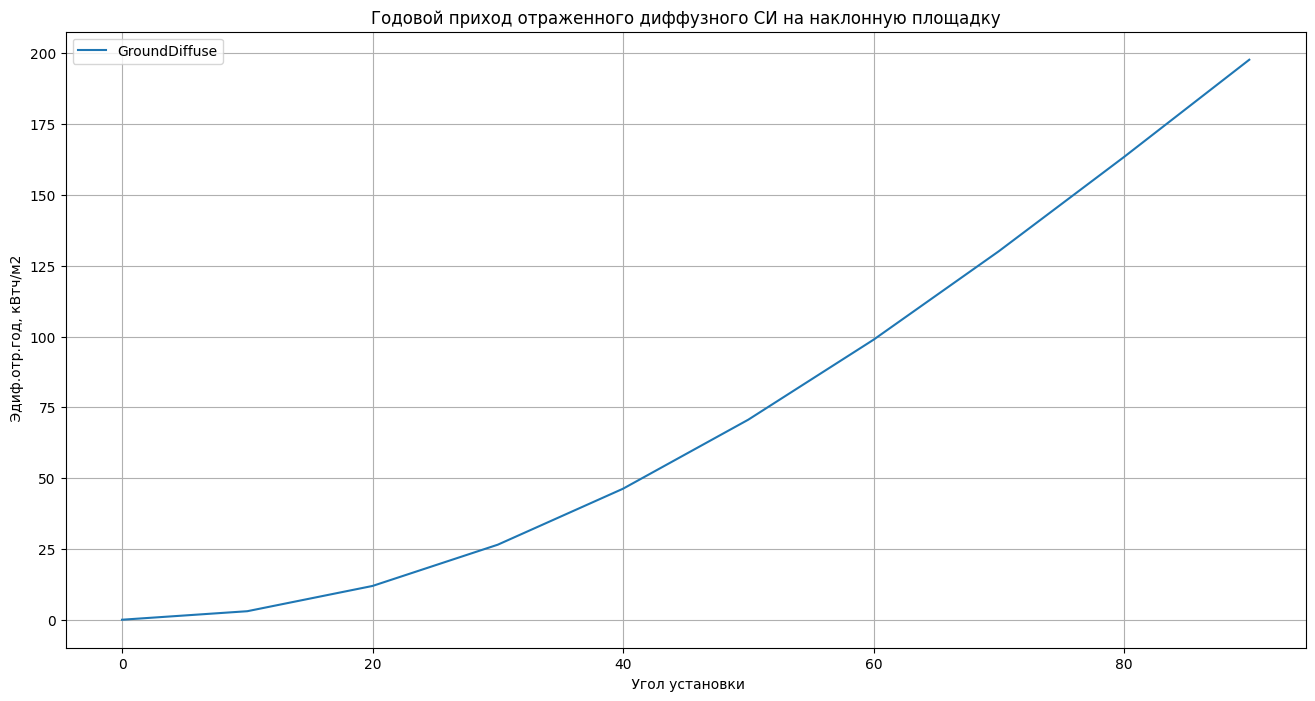

In [26]:
DiffuseGround_Perez = [0.0] * Tilt_range

for i in range (Tilt_range):
    DiffuseGround_Perez[i] = pvlib.irradiance.get_ground_diffuse(surface_tilt = Tilts[i],
                                                                 ghi = PVGIS_data['ghi'],
                                                                 albedo = PVGIS_data['Albedo'],
                                                                 surface_type = None)

Perez_diffuse_ground_data = create_df(Tilts, DiffuseGround_Perez, PVGIS_data.index)

Ground_diff_year_sum = [0] * Tilt_range
for i in range(Tilt_range):
    Ground_diff_year_sum[i] = sum(Perez_diffuse_ground_data[str(Tilts[i])]) / 1000


Perez_year_data['GroundDiffuse'] = Ground_diff_year_sum

Perez_year_data['GroundDiffuse'].plot(figsize = (16,8))
plt.grid()
plt.ylabel(' Эдиф.отр.год, кВтч/м2')
plt.xlabel(' Угол установки')
plt.legend()
plt.title('Годовой приход отраженного диффузного СИ на наклонную площадку')
plt.show()




# Суммарное диффузное СИ

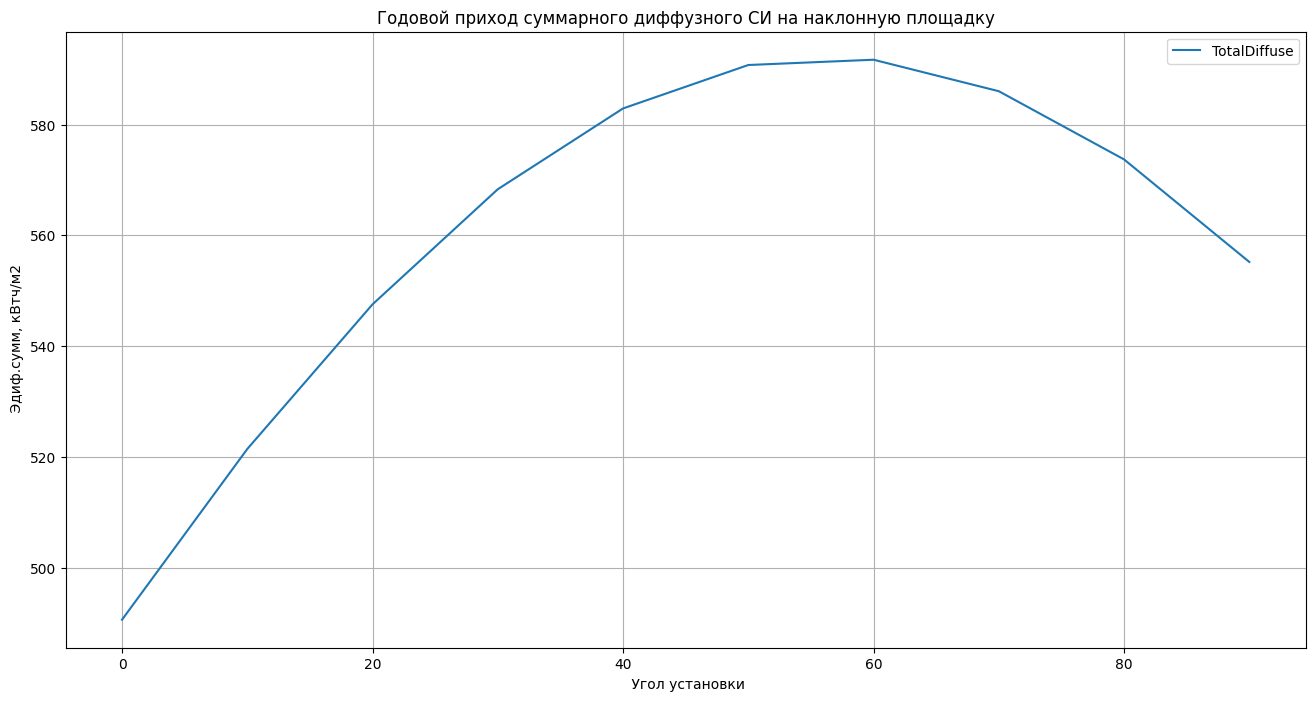

In [27]:
Perez_year_data['TotalDiffuse'] = Perez_year_data['SkyDiffuse'] + Perez_year_data['GroundDiffuse']

Perez_year_data['TotalDiffuse'].plot(figsize = (16,8))
plt.grid()
plt.ylabel(' Эдиф.сумм, кВтч/м2')
plt.xlabel(' Угол установки')
plt.legend()
plt.title('Годовой приход суммарного диффузного СИ на наклонную площадку')
plt.show()



# Угол падения лучей на приемную поверхность AOI

In [28]:
AOI = [0] * Tilt_range

for i in range (Tilt_range):
    AOI[i] = pvlib.irradiance.aoi(surface_tilt = Tilts[i],
                                  surface_azimuth = surface_azimuth,
                                  solar_zenith = SPA_obj['zenith'],
                                  solar_azimuth = SPA_obj['azimuth'])

AOI_data = create_df(Tilts, AOI, PVGIS_data.index)



# Определение оптимальной приемной поверхности (при 1 азимуте, при разных наклонах)

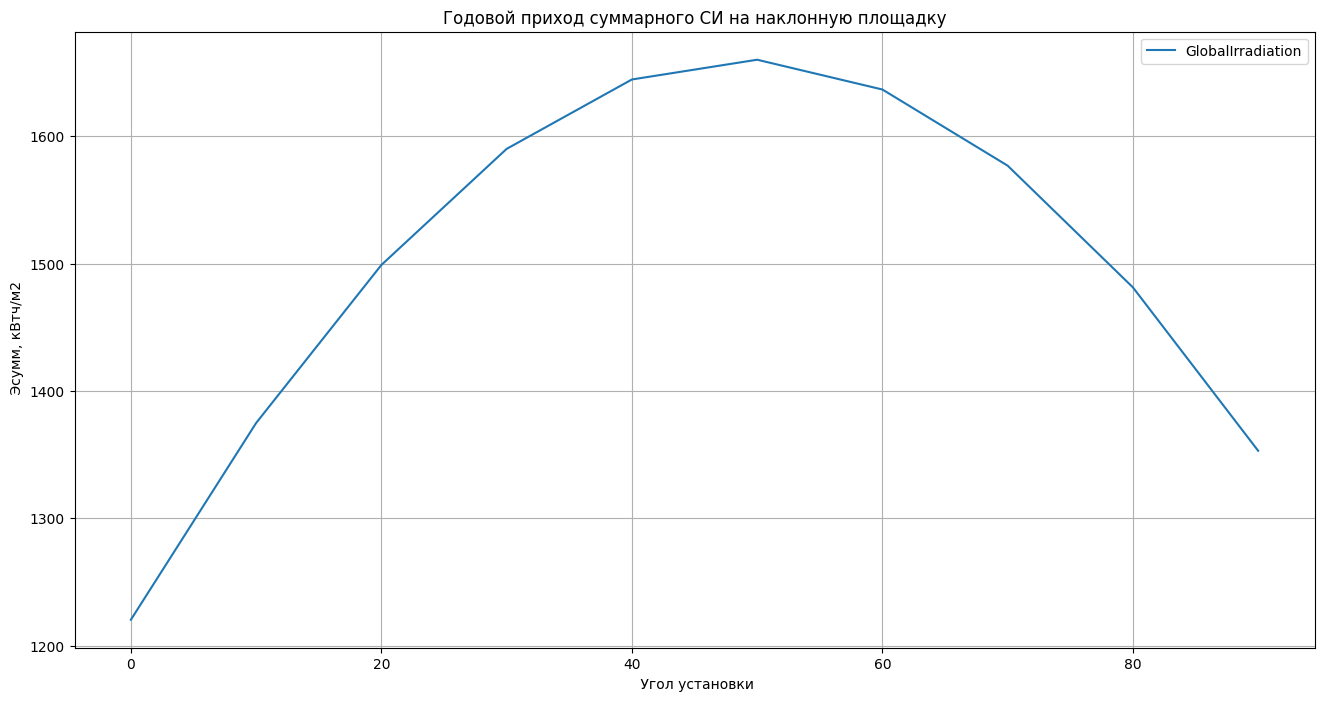

In [29]:
GI_aoi = [0] * Tilt_range
GI_year_Perez = [0] * Tilt_range
pd_transf = {}

for i in range(Tilt_range):
    GI_aoi[i] = pvlib.irradiance.poa_components(aoi = AOI_data[str(Tilts[i])],
                                                 dni = PVGIS_data['dni'],
                                                 poa_sky_diffuse = Perez_diffuse_sky_data[str(Tilts[i])],
                                                 poa_ground_diffuse = Perez_diffuse_ground_data[str(Tilts[i])])


for i in range(Tilt_range):
    pd_transf[str(Tilts[i])] = GI_aoi[i]['poa_global']
    
GI_aoi_data = pd.DataFrame(pd_transf, index = PVGIS_data.index)


for i in range(Tilt_range):
    GI_year_Perez[i] = sum(GI_aoi_data[str(Tilts[i])]) / 1000


Perez_year_data['GlobalIrradiation'] = GI_year_Perez
Perez_year_data['GlobalIrradiation'].plot(figsize = (16,8))
plt.grid()
plt.ylabel(' Эсумм, кВтч/м2')
plt.xlabel(' Угол установки')
plt.legend()
plt.title('Годовой приход суммарного СИ на наклонную площадку')
plt.show()


# Получение графиков нагрузки объекта (жилой сектор)
https://cyberleninka.ru/article/n/organizatsiya-energomenedzhmenta-i-planirovanie-elektricheskoy-nagruzki-domohozyaystv/viewer

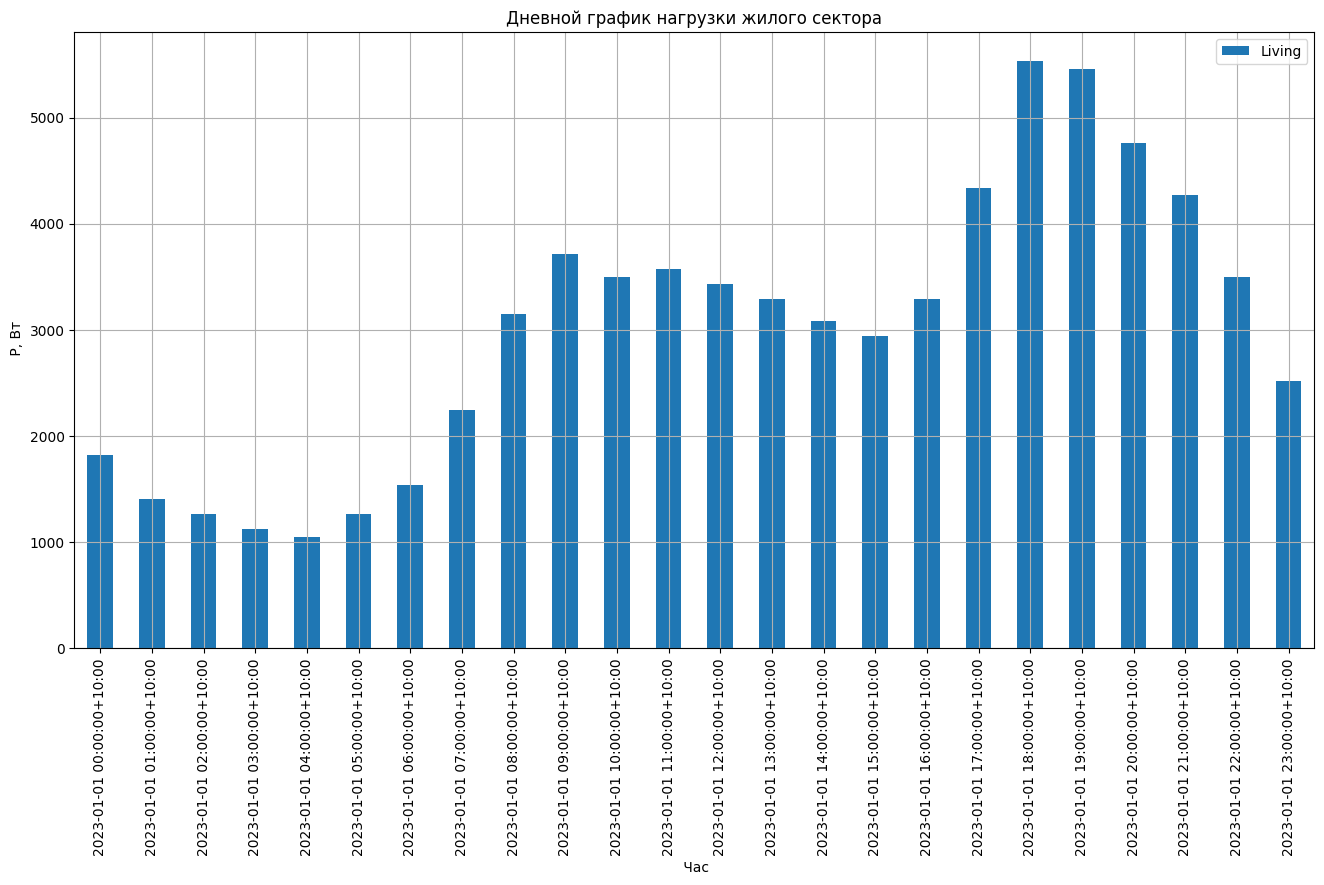

In [30]:
houses_count = 7
household_load_day = [260, 200, 180, 160, 150, 180, 220, 320, 450, 530, 500, 510, 490, 470, 440, 420, 470, 620, 790, 780, 680, 610, 500, 360]
day_len_hours = len(household_load_day)
object_living_load_year = [0.0] * lendata
Load_data = pd.DataFrame(index = PVGIS_data.index)


    
for i in range (lendata):
    hour = int(PVGIS_data.index[i].to_pydatetime().strftime('%H'))
    object_living_load_year[i] = household_load_day[hour]

Load_data['Household'] = object_living_load_year
Load_data['Living'] = Load_data['Household'] * houses_count

Load_data['Living'].iloc[0:24].plot(kind = 'bar', figsize = (16,8))
plt.grid()
plt.ylabel(' P, Вт')
plt.xlabel(' Час')
plt.legend()
plt.title('Дневной график нагрузки жилого сектора')
plt.show()




# Получение данных о ФЭМ

In [31]:
PV_Modules_source = pvlib.pvsystem.retrieve_sam(name = None, path = 'CEC_Modules.csv')
PV_Modules = PV_Modules_source.transpose()
PV_Modules = PV_Modules.rename_axis('Name').reset_index()
PV_Modules

C:\Users\Serg\anaconda3\Lib\site-packages\pvlib\pvsystem.py:2135: UserWarning: Original names contain 505 duplicate(s).
  warnings.warn('Original names contain %d duplicate(s).' % n_duplicates)
C:\Users\Serg\anaconda3\Lib\site-packages\pvlib\pvsystem.py:2139: UserWarning: Normalized names contain 505 duplicate(s).
  warnings.warn(


,Name,Manufacturer,Technology,Bifacial,STC,PTC,A_c,Length,Width,N_s,...,a_ref,I_L_ref,I_o_ref,R_s,R_sh_ref,Adjust,gamma_pmp,BIPV,Version,Date
0,Ablytek_6MN6A270,Ablytek,Mono-c-Si,0,270.643,242.1,1.627,1.64,0.992,60,...,1.58733,9.34243,0.0,0.374013,1440.5,12.6561,-0.4509,N,2023.12.17,11/14/2024
1,Ablytek_6MN6A275,Ablytek,Mono-c-Si,0,275.191,246.7,1.627,1.64,0.992,60,...,1.60182,9.42313,0.0,0.374165,1127.45,12.7242,-0.4509,N,2023.12.17,11/14/2024
2,Ablytek_6MN6A280,Ablytek,Mono-c-Si,0,280.09,251.3,1.627,1.64,0.992,60,...,1.61626,9.51376,0.0,0.37392,945.874,12.784,-0.4509,N,2023.12.17,11/14/2024
3,Ablytek_6MN6A285,Ablytek,Mono-c-Si,0,285.031,256.0,1.627,1.64,0.992,60,...,1.62978,9.59321,0.0,0.374045,1116.6,12.7245,-0.4509,N,2023.12.17,11/14/2024
4,Ablytek_6MN6A290,Ablytek,Mono-c-Si,0,290.016,260.6,1.627,1.64,0.992,60,...,1.64329,9.67267,0.0,0.374168,1357.41,12.666,-0.4509,N,2023.12.17,11/14/2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20738,Zytech_Solar_ZT300P,Zytech Solar,Multi-c-Si,0,300.003,271.2,1.931,1.95,0.99,72,...,1.84441,8.80531,0.0,0.515735,552.453,5.41556,-0.4308,N,2023.12.17,11/14/2024
20739,Zytech_Solar_ZT305P,Zytech Solar,Multi-c-Si,0,305.056,275.8,1.931,1.95,0.99,72,...,1.84915,8.87402,0.0,0.506612,1119.08,5.24155,-0.4308,N,2023.12.17,11/14/2024
20740,Zytech_Solar_ZT310P,Zytech Solar,Multi-c-Si,0,310.144,280.5,1.931,1.95,0.99,72,...,1.8574,8.9948,0.0,0.495904,767.951,5.44635,-0.4308,N,2023.12.17,11/14/2024
20741,Zytech_Solar_ZT315P,Zytech Solar,Multi-c-Si,0,315.094,285.1,1.931,1.95,0.99,72,...,1.86503,9.10661,0.0,0.488376,682.29,5.57875,-0.4308,N,2023.12.17,11/14/2024


# Добавление столбца КПД (eff)

In [32]:
eff_modules = [0.0] * len(PV_Modules)

for i in range(len(eff_modules)):
    eff_modules[i] = PV_Modules['STC'].loc[i] / (PV_Modules['A_c'].loc[i] * 1000)

PV_Modules['eff'] = eff_modules
PV_Modules

,Name,Manufacturer,Technology,Bifacial,STC,PTC,A_c,Length,Width,N_s,...,I_L_ref,I_o_ref,R_s,R_sh_ref,Adjust,gamma_pmp,BIPV,Version,Date,eff
0,Ablytek_6MN6A270,Ablytek,Mono-c-Si,0,270.643,242.1,1.627,1.64,0.992,60,...,9.34243,0.0,0.374013,1440.5,12.6561,-0.4509,N,2023.12.17,11/14/2024,0.166345
1,Ablytek_6MN6A275,Ablytek,Mono-c-Si,0,275.191,246.7,1.627,1.64,0.992,60,...,9.42313,0.0,0.374165,1127.45,12.7242,-0.4509,N,2023.12.17,11/14/2024,0.169140
2,Ablytek_6MN6A280,Ablytek,Mono-c-Si,0,280.09,251.3,1.627,1.64,0.992,60,...,9.51376,0.0,0.37392,945.874,12.784,-0.4509,N,2023.12.17,11/14/2024,0.172151
3,Ablytek_6MN6A285,Ablytek,Mono-c-Si,0,285.031,256.0,1.627,1.64,0.992,60,...,9.59321,0.0,0.374045,1116.6,12.7245,-0.4509,N,2023.12.17,11/14/2024,0.175188
4,Ablytek_6MN6A290,Ablytek,Mono-c-Si,0,290.016,260.6,1.627,1.64,0.992,60,...,9.67267,0.0,0.374168,1357.41,12.666,-0.4509,N,2023.12.17,11/14/2024,0.178252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20738,Zytech_Solar_ZT300P,Zytech Solar,Multi-c-Si,0,300.003,271.2,1.931,1.95,0.99,72,...,8.80531,0.0,0.515735,552.453,5.41556,-0.4308,N,2023.12.17,11/14/2024,0.155361
20739,Zytech_Solar_ZT305P,Zytech Solar,Multi-c-Si,0,305.056,275.8,1.931,1.95,0.99,72,...,8.87402,0.0,0.506612,1119.08,5.24155,-0.4308,N,2023.12.17,11/14/2024,0.157978
20740,Zytech_Solar_ZT310P,Zytech Solar,Multi-c-Si,0,310.144,280.5,1.931,1.95,0.99,72,...,8.9948,0.0,0.495904,767.951,5.44635,-0.4308,N,2023.12.17,11/14/2024,0.160613
20741,Zytech_Solar_ZT315P,Zytech Solar,Multi-c-Si,0,315.094,285.1,1.931,1.95,0.99,72,...,9.10661,0.0,0.488376,682.29,5.57875,-0.4308,N,2023.12.17,11/14/2024,0.163177


# Получение ФЭМ по заданным параметрам

In [33]:
PV_Modules_chosen1 = pd.DataFrame(columns = PV_Modules.columns)

PV_P_min_1 = 300
PV_type_1 = 'Mono-c-Si'
PV_bifacial_1 = 0
PV_V_oc_ref_1 = 0
Square_max_1 = 2
eff_min_1 = 0.2

ind = 0
for i in range(len(PV_Modules)):
    if math.isnan(PV_Modules['Length'].iloc[i]) == False: # Проверка на наличие данных о габаритах
        if PV_Modules['STC'].iloc[i] >= PV_P_min_1: # по мощности
            if PV_Modules['Technology'].iloc[i] == PV_type_1: # по типу СЭ, может быть:
                                                                 # CdTe
                                                                 # CIGS
                                                                 # Mono-c-Si
                                                                 # Multi-c-Si
                                                                 # Thin Film
                if PV_Modules['Bifacial'].iloc[i] == PV_bifacial_1: # односторонний (0) или двусторонний (1)
                    if PV_Modules['V_oc_ref'].iloc[i] > PV_V_oc_ref_1: # по величине напряжения холостого хода
                        if PV_Modules['A_c'].iloc[i] < Square_max_1: # по площади
                            if PV_Modules['eff'].iloc[i] > eff_min_1: # по КПД
                                PV_Modules_chosen1.loc[ind] = PV_Modules.iloc[i]
                                ind += 1

PV_Modules_chosen2 = pd.DataFrame(columns = PV_Modules.columns)

PV_P_min_2 = 400
PV_type_2 = 'Mono-c-Si'
PV_bifacial_2 = 0
PV_V_oc_ref_2 = 45
Square_max_2 = 3
eff_min_2 = 0.19

ind = 0
for i in range(len(PV_Modules)):
    if math.isnan(PV_Modules['Length'].iloc[i]) == False: # Проверка на наличие данных о габаритах
        if PV_Modules['STC'].iloc[i] >= PV_P_min_2: # по мощности
            if PV_Modules['Technology'].iloc[i] == PV_type_2: # по типу СЭ, может быть:
                                                                 # CdTe
                                                                 # CIGS
                                                                 # Mono-c-Si
                                                                 # Multi-c-Si
                                                                 # Thin Film
                if PV_Modules['Bifacial'].iloc[i] == PV_bifacial_2: # односторонний (0) или двусторонний (1)
                    if PV_Modules['V_oc_ref'].iloc[i] > PV_V_oc_ref_2: # по величине напряжения холостого хода
                        if PV_Modules['A_c'].iloc[i] < Square_max_2: # по площади
                            if PV_Modules['eff'].iloc[i] > eff_min_2: # по КПД
                                PV_Modules_chosen2.loc[ind] = PV_Modules.iloc[i]
                                ind += 1
PV_Modules_chosen2

PV_Modules_chosen3 = pd.DataFrame(columns = PV_Modules.columns)

PV_P_min_3 = 200
PV_type_3 = 'Mono-c-Si'
PV_bifacial_3 = 0
PV_V_oc_ref_3 = 0
Square_max_3 = 1.5
eff_min_3 = 0.2

ind = 0
for i in range(len(PV_Modules)):
    if math.isnan(PV_Modules['Length'].iloc[i]) == False: # Проверка на наличие данных о габаритах
        if PV_Modules['STC'].iloc[i] >= PV_P_min_3: # по мощности
            if PV_Modules['Technology'].iloc[i] == PV_type_3: # по типу СЭ, может быть:
                                                                 # CdTe
                                                                 # CIGS
                                                                 # Mono-c-Si
                                                                 # Multi-c-Si
                                                                 # Thin Film
                if PV_Modules['Bifacial'].iloc[i] == PV_bifacial_3: # односторонний (0) или двусторонний (1)
                    if PV_Modules['V_oc_ref'].iloc[i] > PV_V_oc_ref_3: # по величине напряжения холостого хода
                        if PV_Modules['A_c'].iloc[i] < Square_max_3: # по площади
                            if PV_Modules['eff'].iloc[i] > eff_min_3: # по КПД
                                PV_Modules_chosen3.loc[ind] = PV_Modules.iloc[i]
                                ind += 1


# Вручную выбираем 3-х кандидатов подходящих под параметры

In [34]:
PV_modules_candidates = pd.DataFrame(columns = PV_Modules.columns)

PV_modules_candidates.loc[0] = PV_Modules_chosen1.iloc[0]
PV_modules_candidates.loc[1] = PV_Modules_chosen2.iloc[0]
PV_modules_candidates.loc[2] = PV_Modules_chosen3.iloc[0]

Candidates_len = len(PV_modules_candidates)

PV_modules_candidates

,Name,Manufacturer,Technology,Bifacial,STC,PTC,A_c,Length,Width,N_s,...,I_L_ref,I_o_ref,R_s,R_sh_ref,Adjust,gamma_pmp,BIPV,Version,Date,eff
0,AU_Optronics_PM096B00_327,AU Optronics,Mono-c-Si,0,327.106,299.3,1.631,1.559,1.046,96,...,6.46832,0.0,0.364689,283.267,10.0383,-0.377,N,2023.12.17,11/14/2024,0.200555
1,LG_Electronics_Inc__LG400N2C_A5,LG Electronics Inc.,Mono-c-Si,0,400.316,368.4,2.0,2.0,1.0,72,...,10.4811,0.0,0.312859,293.807,9.38061,-0.36,N,2023.12.17,11/14/2024,0.200158
2,SunPower_SPR_250NX_BLK_D,SunPower,Mono-c-Si,0,249.952,231.7,1.244,1.559,0.798,72,...,6.20451,0.0,0.362431,498.476,4.39638,-0.39,N,2023.12.17,11/14/2024,0.200926


# Текстовый вывод параметров

In [35]:
for i in range(Candidates_len):
    print('Название',PV_modules_candidates['Name'].loc[i])
    print('Пиковая мощность',PV_modules_candidates['STC'].loc[i])
    print('Длина',PV_modules_candidates['Length'].loc[i] * 1000, 'x',PV_modules_candidates['Width'].loc[i] * 1000)
    print('Ток КЗ',PV_modules_candidates['I_sc_ref'].loc[i])
    print('Напряжение ХХ',PV_modules_candidates['V_oc_ref'].loc[i])
    print('Ток ТММ',PV_modules_candidates['I_mp_ref'].loc[i])
    print('Напряжение ТММ',PV_modules_candidates['V_mp_ref'].loc[i])
    print('Температурный коэф. КЗ',PV_modules_candidates['alpha_sc'].loc[i])
    print('Температурный коэф. ХХ',PV_modules_candidates['beta_oc'].loc[i])
    print('Температурный коэф мощности',PV_modules_candidates['gamma_pmp'].loc[i])
    print('Тип ФЭМ',PV_modules_candidates['Technology'].loc[i])
    print('Тип ФЭМ',round(PV_modules_candidates['eff'].loc[i],4))
    print('')

Название AU_Optronics_PM096B00_327
Пиковая мощность 327.106
Длина 1559.0 x 1046.0
Ток КЗ 6.46
Напряжение ХХ 64.9
Ток ТММ 5.98
Напряжение ТММ 54.7
Температурный коэф. КЗ 0.0040052
Температурный коэф. ХХ -0.198594
Температурный коэф мощности -0.377
Тип ФЭМ Mono-c-Si
Тип ФЭМ 0.2006

Название LG_Electronics_Inc__LG400N2C_A5
Пиковая мощность 400.316
Длина 2000.0 x 1000.0
Ток КЗ 10.47
Напряжение ХХ 49.3
Ток ТММ 9.86
Напряжение ТММ 40.6
Температурный коэф. КЗ 0.003141
Температурный коэф. ХХ -0.12818
Температурный коэф мощности -0.36
Тип ФЭМ Mono-c-Si
Тип ФЭМ 0.2002

Название SunPower_SPR_250NX_BLK_D
Пиковая мощность 249.952
Длина 1559.0 x 798.0
Ток КЗ 6.2
Напряжение ХХ 50.93
Ток ТММ 5.84
Напряжение ТММ 42.8
Температурный коэф. КЗ 0.0008246
Температурный коэф. ХХ -0.148206
Температурный коэф мощности -0.39
Тип ФЭМ Mono-c-Si
Тип ФЭМ 0.2009



# Расчет температуры модулей

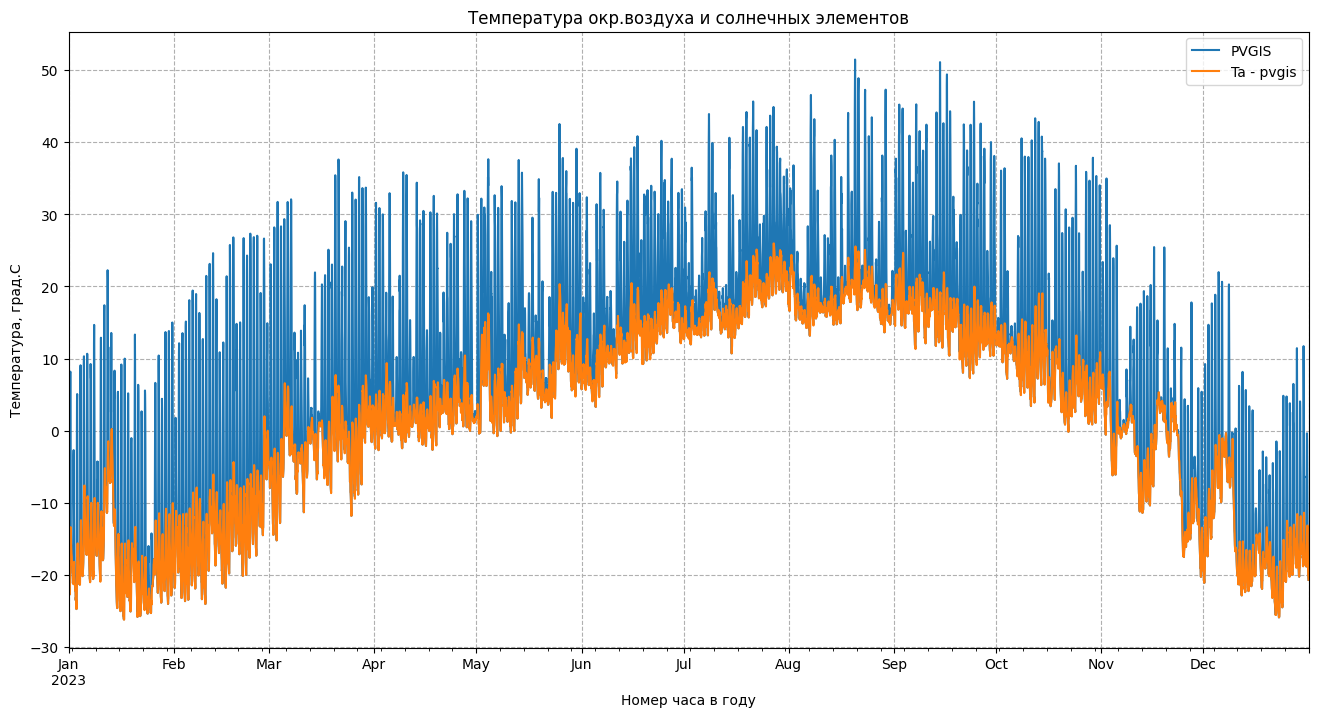

Минимальная температура модуля -26.16
Максимальная температура модуля 51.45


In [36]:
a = -3.56
b = -0.075
deltaT = 3
opt_tilt = 50

Cells_temperature_PVGIS = pvlib.temperature.sapm_cell(GI_aoi_data[str(opt_tilt)], 
                            PVGIS_data['temp_air'], 
                            PVGIS_data['wind_speed'], 
                            a, 
                            b, 
                            deltaT, 
                            irrad_ref=1000.0)

#Cells_temperature_NASA.plot(figsize=(16,8), label='NASA')
Cells_temperature_PVGIS.plot(figsize=(16,8), label='PVGIS')
PVGIS_data['temp_air'].plot(label='Ta - pvgis')
plt.legend()
plt.grid(linestyle='--')
plt.ylabel('Температура, град.C')
plt.xlabel('Номер часа в году')
plt.title('Температура окр.воздуха и солнечных элементов')
plt.show()

print('Минимальная температура модуля', round(Cells_temperature_PVGIS.min(), 2))
print('Максимальная температура модуля', round(Cells_temperature_PVGIS.max(), 2))

# Выработка на стороне постоянного тока


In [37]:
DC_out = [0.0] * Candidates_len

for i in range (Candidates_len):
    Module = PV_modules_candidates.iloc[i]
    I_L, I_0, R_s, R_sh, nNsVth = pvlib.pvsystem.calcparams_desoto(effective_irradiance = GI_aoi_data[str(opt_tilt)],
                                                                   temp_cell = Cells_temperature_PVGIS,
                                                                   alpha_sc = Module['alpha_sc'],
                                                                   a_ref = Module['a_ref'],
                                                                   I_L_ref = Module['I_L_ref'],
                                                                   I_o_ref = Module['I_o_ref'],
                                                                   R_sh_ref = Module['R_sh_ref'],
                                                                   R_s = Module['R_s'],
                                                                   EgRef = 1.121,
                                                                   dEgdT = -0.0002677,
                                                                   irrad_ref = 1000,
                                                                   temp_ref = 25)
                                                                   
                                                                   
    
    DC_out[i] = pvlib.pvsystem.singlediode(photocurrent = I_L,
                               saturation_current = I_0 , 
                               resistance_series = R_s, 
                               resistance_shunt = R_sh,
                               nNsVth = nNsVth,
                               method = 'newton')
    
DC_out_module_1_data = DC_out[0]
DC_out_module_2_data = DC_out[1]
DC_out_module_3_data = DC_out[2]
print(sum(DC_out_module_1_data['p_mp']))
print(sum(DC_out_module_2_data['p_mp']))
print(sum(DC_out_module_3_data['p_mp']))

544460.3664276915
674946.6680170315
418196.84362993704


# Выбор инверторов

In [38]:
PV_Inverters_source = pvlib.pvsystem.retrieve_sam(name=None, path='CEC_Inverters.csv')
PV_Inverters = PV_Inverters_source.transpose()
PV_Inverters = PV_Inverters.rename_axis('Name').reset_index()
PV_Inverters


,Name,Vac,Pso,Paco,Pdco,Vdco,C0,C1,C2,C3,Pnt,Vdcmax,Idcmax,Mppt_low,Mppt_high,CEC_Date,CEC_hybrid
0,ABB__PVI_3_0_OUTD_S_US_A__208V_,208,18.1674,3000.0,3142.3,310.0,-0.000008,-0.000011,0.000999,-0.000287,0.1,480.0,10.1365,100.0,480.0,10/15/2018,N
1,ABB__PVI_3_0_OUTD_S_US_A__240V_,240,16.8813,3000.0,3121.67,340.0,-0.000006,-0.000021,0.000583,-0.000712,0.1,480.0,9.18138,100.0,480.0,10/15/2018,N
2,ABB__PVI_3_0_OUTD_S_US_A__277V_,277,22.0466,3000.0,3106.85,390.0,-0.000005,-0.000033,-0.000032,-0.00118,0.2,480.0,7.96628,100.0,480.0,10/15/2018,N
3,ABB__PVI_3_0_OUTD_S_US_Z_A__208V_,208,18.1674,3000.0,3142.3,310.0,-0.000008,-0.000011,0.000999,-0.000287,0.1,480.0,10.1365,100.0,480.0,10/15/2018,N
4,ABB__PVI_3_0_OUTD_S_US_Z_A__240V_,240,16.8813,3000.0,3121.67,340.0,-0.000006,-0.000021,0.000583,-0.000712,0.1,480.0,9.18138,100.0,480.0,10/15/2018,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2079,Zhejiang_Hyxi_Technology_Co___Ltd__HYX_M800_S_...,240,1.3483,723.0,753.434,42.0,-0.000015,0.000177,-0.00665,0.004603,0.4,50.0,17.9389,35.0,50.0,11/1/2024,N
2080,Zhejiang_Hyxi_Technology_Co___Ltd__HYX_M800_SW...,208,2.08855,800.39,835.094,42.0,-0.000013,-0.000413,-0.004319,-0.107438,0.23,50.0,19.8832,35.0,50.0,NaN,N
2081,Zhejiang_Hyxi_Technology_Co___Ltd__HYX_M800_SW...,240,6.4626,800.124,846.227,42.0,-0.000083,-0.001306,0.005864,-0.023282,0.23,50.0,20.1483,35.0,50.0,NaN,N
2082,Zhejiang_Hyxi_Technology_Co___Ltd__HYX_M800_SW...,208,0.975306,721.0,751.212,42.0,-0.000013,0.000275,0.098651,0.075813,0.3,50.0,17.886,35.0,50.0,11/1/2024,N


# Выбор инверторов по заданным параметрам

In [39]:

def inverter_selection(columns, V_ac, P_ac_max, P_ac_min, I_dc_max, V_dc_min, PV_Inverters):
    PV_Inverters_chosen = pd.DataFrame(columns = columns)
    ind = 0
    
    for i in range(len(PV_Inverters)):
        if PV_Inverters['Vac'].iloc[i] == V_ac:
            if (PV_Inverters['Paco'].iloc[i] >= P_ac_min) and  (PV_Inverters['Paco'].iloc[i] <= P_ac_max): # по мощности
                if PV_Inverters['Idcmax'].iloc[i] < I_dc_max:
                    if PV_Inverters['Vdcmax'].iloc[i] > V_dc_min:
                        PV_Inverters_chosen.loc[ind] = PV_Inverters.iloc[i]
                        ind += 1

    return PV_Inverters_chosen

V_ac_1 = 240
P_ac_max_1 = 12000
P_ac_min_1 = 9000
I_dc_max_1 = 24
V_dc_min_1 = 600
PV_Inverters_chosen1 = inverter_selection(columns = PV_Inverters.columns,
                                         V_ac = V_ac_1,
                                         P_ac_max = P_ac_max_1,
                                         P_ac_min = P_ac_min_1,
                                         I_dc_max = I_dc_max_1,
                                         V_dc_min = V_dc_min_1,
                                         PV_Inverters = PV_Inverters)

V_ac_2 = 240
P_ac_max_2 = 3500
P_ac_min_2 = 3000
I_dc_max_2 = 12
V_dc_min_2 = 300
PV_Inverters_chosen2 = inverter_selection(columns = PV_Inverters.columns,
                                         V_ac = V_ac_2,
                                         P_ac_max = P_ac_max_2,
                                         P_ac_min = P_ac_min_2,
                                         I_dc_max = I_dc_max_2,
                                         V_dc_min = V_dc_min_2,
                                         PV_Inverters = PV_Inverters)

V_ac_3 = 240
P_ac_max_3 = 20000
P_ac_min_3 = 15000
I_dc_max_3 = 50
V_dc_min_3 = 400
PV_Inverters_chosen3 = inverter_selection(columns = PV_Inverters.columns,
                                         V_ac = V_ac_3,
                                         P_ac_max = P_ac_max_3,
                                         P_ac_min = P_ac_min_3,
                                         I_dc_max = I_dc_max_3,
                                         V_dc_min = V_dc_min_3,
                                         PV_Inverters = PV_Inverters)

PV_Inverters_candidates = pd.DataFrame(columns = PV_Inverters.columns)

PV_Inverters_candidates.loc[0] = PV_Inverters_chosen1.iloc[0]
PV_Inverters_candidates.loc[1] = PV_Inverters_chosen2.iloc[0]
PV_Inverters_candidates.loc[2] = PV_Inverters_chosen3.iloc[0]

PV_Inverters_candidates

,Name,Vac,Pso,Paco,Pdco,Vdco,C0,C1,C2,C3,Pnt,Vdcmax,Idcmax,Mppt_low,Mppt_high,CEC_Date,CEC_hybrid
0,Fronius_International_GmbH__Fronius_Primo_10_0...,240,44.2769,9995.0,10296.0,655.0,-0.000001,-0.000028,-0.00062,0.000286,0.32,800.0,15.7191,100.0,800.0,3/1/2019,N
1,ABB__PVI_3_0_OUTD_S_US_A__240V_,240,16.8813,3000.0,3121.67,340.0,-0.000006,-0.000021,0.000583,-0.000712,0.1,480.0,9.18138,100.0,480.0,10/15/2018,N
2,Fronius_International_GmbH__Fronius_Primo_15_0...,240,55.7458,15000.0,15456.2,680.0,-0.000001,-0.000028,-0.000709,-0.000289,0.32,800.0,22.7297,320.0,800.0,3/1/2019,N


# Текстовый вывод праметров

In [40]:
for i in range(Candidates_len):
    print('Название',PV_Inverters_candidates['Name'].loc[i])
    print('Мощность АС',PV_Inverters_candidates['Paco'].loc[i])
    print('Мощность DC',PV_Inverters_candidates['Pdco'].loc[i])
    print('Напряжение MPPT min',PV_Inverters_candidates['Mppt_low'].loc[i])
    print('Напряжение MPPT max',PV_Inverters_candidates['Mppt_high'].loc[i])
    print('Ток DC max',PV_Inverters_candidates['Idcmax'].loc[i])

    print('')

Название Fronius_International_GmbH__Fronius_Primo_10_0_1_208_240__240V_
Мощность АС 9995.0
Мощность DC 10296.0
Напряжение MPPT min 100.0
Напряжение MPPT max 800.0
Ток DC max 15.7191

Название ABB__PVI_3_0_OUTD_S_US_A__240V_
Мощность АС 3000.0
Мощность DC 3121.67
Напряжение MPPT min 100.0
Напряжение MPPT max 480.0
Ток DC max 9.18138

Название Fronius_International_GmbH__Fronius_Primo_15_0_1_208_240__240V_
Мощность АС 15000.0
Мощность DC 15456.2
Напряжение MPPT min 320.0
Напряжение MPPT max 800.0
Ток DC max 22.7297



# Схема компановки выбранных ФЭМ и иневерторов (Последовательно)

In [41]:
PV_V_OC_max_array = [0.0] * Candidates_len

PV_V_OC_max_array[0] = max(max(DC_out_module_1_data['v_oc']), 
    PV_modules_candidates['V_oc_ref'].iloc[0])
PV_V_OC_max_array[1] = max(max(DC_out_module_2_data['v_oc']), 
    PV_modules_candidates['V_oc_ref'].iloc[1])
PV_V_OC_max_array[2] = max(max(DC_out_module_3_data['v_oc']), 
    PV_modules_candidates['V_oc_ref'].iloc[2])

Scheme_series_data = pd.DataFrame(columns = PV_modules_candidates['Name'],
                                  index = PV_Inverters_candidates['Name'])

for i in range (Candidates_len):
    for j in range (Candidates_len):
        s_1 = PV_Inverters_candidates['Vdcmax'].iloc[j] // PV_V_OC_max_array[i]
        print('К инвертору №', j+1, 'можно подключить', s_1, 'ФЭМ №', i+1,' соединённых последовательно.')
        Scheme_series_data.iloc[j,i] = s_1


    print('')
Scheme_series_data
                        
        

    

К инвертору № 1 можно подключить 11.0 ФЭМ № 1  соединённых последовательно.
К инвертору № 2 можно подключить 6.0 ФЭМ № 1  соединённых последовательно.
К инвертору № 3 можно подключить 11.0 ФЭМ № 1  соединённых последовательно.

К инвертору № 1 можно подключить 14.0 ФЭМ № 2  соединённых последовательно.
К инвертору № 2 можно подключить 8.0 ФЭМ № 2  соединённых последовательно.
К инвертору № 3 можно подключить 14.0 ФЭМ № 2  соединённых последовательно.

К инвертору № 1 можно подключить 14.0 ФЭМ № 3  соединённых последовательно.
К инвертору № 2 можно подключить 8.0 ФЭМ № 3  соединённых последовательно.
К инвертору № 3 можно подключить 14.0 ФЭМ № 3  соединённых последовательно.



Name,AU_Optronics_PM096B00_327,LG_Electronics_Inc__LG400N2C_A5,SunPower_SPR_250NX_BLK_D
Name,,,
Fronius_International_GmbH__Fronius_Primo_10_0_1_208_240__240V_,11.0,14.0,14.0
ABB__PVI_3_0_OUTD_S_US_A__240V_,6.0,8.0,8.0
Fronius_International_GmbH__Fronius_Primo_15_0_1_208_240__240V_,11.0,14.0,14.0


# Параллельно

In [42]:
PV_I_SC_max_array = [0.0] * Candidates_len

PV_I_SC_max_array[0] = max(max(DC_out_module_1_data['i_sc']), 
    PV_modules_candidates['I_sc_ref'].iloc[0])
PV_I_SC_max_array[1] = max(max(DC_out_module_2_data['i_sc']), 
    PV_modules_candidates['I_sc_ref'].iloc[1])
PV_I_SC_max_array[2] = max(max(DC_out_module_3_data['i_sc']), 
    PV_modules_candidates['I_sc_ref'].iloc[2])

Scheme_parallel_data = pd.DataFrame(columns = PV_modules_candidates['Name'],
                                  index = PV_Inverters_candidates['Name'])

for i in range (Candidates_len):
    for j in range (Candidates_len):
        s_1 = PV_Inverters_candidates['Idcmax'].iloc[j] // PV_I_SC_max_array[i]
        print('К инвертору №', j+1, 'можно подключить', s_1, 'ФЭМ №', i+1,' параллельно.')
        Scheme_parallel_data.iloc[j,i] = s_1


    print('')
Scheme_parallel_data

К инвертору № 1 можно подключить 2.0 ФЭМ № 1  параллельно.
К инвертору № 2 можно подключить 1.0 ФЭМ № 1  параллельно.
К инвертору № 3 можно подключить 3.0 ФЭМ № 1  параллельно.

К инвертору № 1 можно подключить 1.0 ФЭМ № 2  параллельно.
К инвертору № 2 можно подключить 0.0 ФЭМ № 2  параллельно.
К инвертору № 3 можно подключить 1.0 ФЭМ № 2  параллельно.

К инвертору № 1 можно подключить 2.0 ФЭМ № 3  параллельно.
К инвертору № 2 можно подключить 1.0 ФЭМ № 3  параллельно.
К инвертору № 3 можно подключить 3.0 ФЭМ № 3  параллельно.



Name,AU_Optronics_PM096B00_327,LG_Electronics_Inc__LG400N2C_A5,SunPower_SPR_250NX_BLK_D
Name,,,
Fronius_International_GmbH__Fronius_Primo_10_0_1_208_240__240V_,2.0,1.0,2.0
ABB__PVI_3_0_OUTD_S_US_A__240V_,1.0,0.0,1.0
Fronius_International_GmbH__Fronius_Primo_15_0_1_208_240__240V_,3.0,1.0,3.0


# Проверка по мощности

In [43]:
Scheme_total_data = pd.DataFrame(columns = Scheme_parallel_data.columns,
                                 index = Scheme_parallel_data.index)

Scheme_total_data = Scheme_parallel_data * Scheme_series_data
Scheme_total_data




Name,AU_Optronics_PM096B00_327,LG_Electronics_Inc__LG400N2C_A5,SunPower_SPR_250NX_BLK_D
Name,,,
Fronius_International_GmbH__Fronius_Primo_10_0_1_208_240__240V_,22.0,14.0,28.0
ABB__PVI_3_0_OUTD_S_US_A__240V_,6.0,0.0,8.0
Fronius_International_GmbH__Fronius_Primo_15_0_1_208_240__240V_,33.0,14.0,42.0


In [44]:
k_power_inverter = 1.1
PV_Inverters_candidates['P_max'] = PV_Inverters_candidates['Pdco'] * k_power_inverter

PV_P_max_array = [0.0] * Candidates_len
PV_P_max_array[0] = max(max(DC_out_module_1_data['p_mp']), 
    PV_modules_candidates['STC'].iloc[0])
PV_P_max_array[1] = max(max(DC_out_module_2_data['p_mp']), 
    PV_modules_candidates['STC'].iloc[1])
PV_P_max_array[2] = max(max(DC_out_module_3_data['p_mp']), 
    PV_modules_candidates['STC'].iloc[2])

Scheme_power_data = pd.DataFrame(columns = PV_modules_candidates['Name'],
                                  index = PV_Inverters_candidates['Name'])

for i in range (Candidates_len):
    for j in range (Candidates_len):
        s_1 = PV_Inverters_candidates['P_max'].iloc[j] // PV_P_max_array[i]
        print('К инвертору №', j+1, 'можно подключить', s_1, 'ФЭМ №', i+1)
        Scheme_power_data.iloc[j,i] = s_1

Scheme_power_data

К инвертору № 1 можно подключить 29.0 ФЭМ № 1
К инвертору № 2 можно подключить 8.0 ФЭМ № 1
К инвертору № 3 можно подключить 44.0 ФЭМ № 1
К инвертору № 1 можно подключить 24.0 ФЭМ № 2
К инвертору № 2 можно подключить 7.0 ФЭМ № 2
К инвертору № 3 можно подключить 36.0 ФЭМ № 2
К инвертору № 1 можно подключить 38.0 ФЭМ № 3
К инвертору № 2 можно подключить 11.0 ФЭМ № 3
К инвертору № 3 можно подключить 57.0 ФЭМ № 3


Name,AU_Optronics_PM096B00_327,LG_Electronics_Inc__LG400N2C_A5,SunPower_SPR_250NX_BLK_D
Name,,,
Fronius_International_GmbH__Fronius_Primo_10_0_1_208_240__240V_,29.0,24.0,38.0
ABB__PVI_3_0_OUTD_S_US_A__240V_,8.0,7.0,11.0
Fronius_International_GmbH__Fronius_Primo_15_0_1_208_240__240V_,44.0,36.0,57.0


# Проверка соответствия схемы

In [45]:
Scheme_checker_data = pd.DataFrame(columns = PV_modules_candidates['Name'],
                                  index = PV_Inverters_candidates['Name'])

for i in range(Candidates_len):
    for j in range(Candidates_len):
        if Scheme_power_data.iloc[i,j] >= Scheme_total_data.iloc[i,j]:
            Scheme_checker_data.iloc[i,j] = True
        else:
            Scheme_checker_data.iloc[i,j] = False

Scheme_checker_data

#Если TRUE, то можно выбрать схему по Scheme_total_data, Scheme_parallel_data, и Scheme_series_data

Name,AU_Optronics_PM096B00_327,LG_Electronics_Inc__LG400N2C_A5,SunPower_SPR_250NX_BLK_D
Name,,,
Fronius_International_GmbH__Fronius_Primo_10_0_1_208_240__240V_,True,True,True
ABB__PVI_3_0_OUTD_S_US_A__240V_,True,True,True
Fronius_International_GmbH__Fronius_Primo_15_0_1_208_240__240V_,True,True,True


# Загрузка инвертора

In [46]:
k_load_inverter_data = pd.DataFrame(columns = PV_modules_candidates['Name'],
                                  index = PV_Inverters_candidates['Name'])

for i in range(Candidates_len):
    for j in range(Candidates_len):
        s_1 = PV_P_max_array[i] * Scheme_total_data.iloc[j,i] / PV_Inverters_candidates['Pdco'].iloc[j]
        k_load_inverter_data.iloc[j,i] = s_1

k_load_inverter_data

Name,AU_Optronics_PM096B00_327,LG_Electronics_Inc__LG400N2C_A5,SunPower_SPR_250NX_BLK_D
Name,,,
Fronius_International_GmbH__Fronius_Primo_10_0_1_208_240__240V_,0.821137,0.635441,0.798125
ABB__PVI_3_0_OUTD_S_US_A__240V_,0.738628,0.0,0.752116
Fronius_International_GmbH__Fronius_Primo_15_0_1_208_240__240V_,0.820489,0.423293,0.797495


# Расчет Киум (сторона переменного тока в процентах)

In [47]:
AC_out_1 = [0] * Candidates_len
AC_out_2 = [0] * Candidates_len
AC_out_3 = [0] * Candidates_len

kium_ac_1 = [0] * Candidates_len
kium_ac_2 = [0] * Candidates_len
kium_ac_3 = [0] * Candidates_len

kium_ac_data = pd.DataFrame(columns = PV_modules_candidates['Name'],
                                  index = PV_Inverters_candidates['Name'])


for i in range(Candidates_len):
    AC_out_1[i] = pvlib.inverter.sandia(
        DC_out_module_1_data['v_mp'] * Scheme_series_data.iloc[i,0],
        DC_out_module_1_data['p_mp'] * Scheme_total_data.iloc[i,0],
        PV_Inverters_candidates.iloc[i])
    kium_ac_data.iloc[i,0] = sum(AC_out_1[i]) / (PV_Inverters_candidates['Paco'].iloc[i] * lendata) * 100
    
    AC_out_2[i] = pvlib.inverter.sandia(
        DC_out_module_2_data['v_mp'] * Scheme_series_data.iloc[i,1], 
        DC_out_module_2_data['p_mp'] * Scheme_total_data.iloc[i,1], 
        PV_Inverters_candidates.iloc[i])
    kium_ac_data.iloc[i,1] = sum(AC_out_2[i]) / (PV_Inverters_candidates['Paco'].iloc[i] * lendata) * 100
    
    AC_out_3[i] = pvlib.inverter.sandia(
        DC_out_module_3_data['v_mp'] * Scheme_series_data.iloc[i,2], 
        DC_out_module_3_data['p_mp'] * Scheme_total_data.iloc[i,2], 
        PV_Inverters_candidates.iloc[i])
    kium_ac_data.iloc[i,2] = sum(AC_out_3[i]) / (PV_Inverters_candidates['Paco'].iloc[i] * lendata) * 100


kium_ac_data        
        

Name,AU_Optronics_PM096B00_327,LG_Electronics_Inc__LG400N2C_A5,SunPower_SPR_250NX_BLK_D
Name,,,
Fronius_International_GmbH__Fronius_Primo_10_0_1_208_240__240V_,13.162204,10.336366,12.863185
ABB__PVI_3_0_OUTD_S_US_A__240V_,11.873681,-0.003333,12.164977
Fronius_International_GmbH__Fronius_Primo_15_0_1_208_240__240V_,13.193605,6.8641,12.895209


# Выработка выбранной конфигурацией

C:\Users\Serg\AppData\Local\Temp\ipykernel_16956\3767295192.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  AC_out_final_months[month - 1] += float(AC_out_final[i]) / 1000


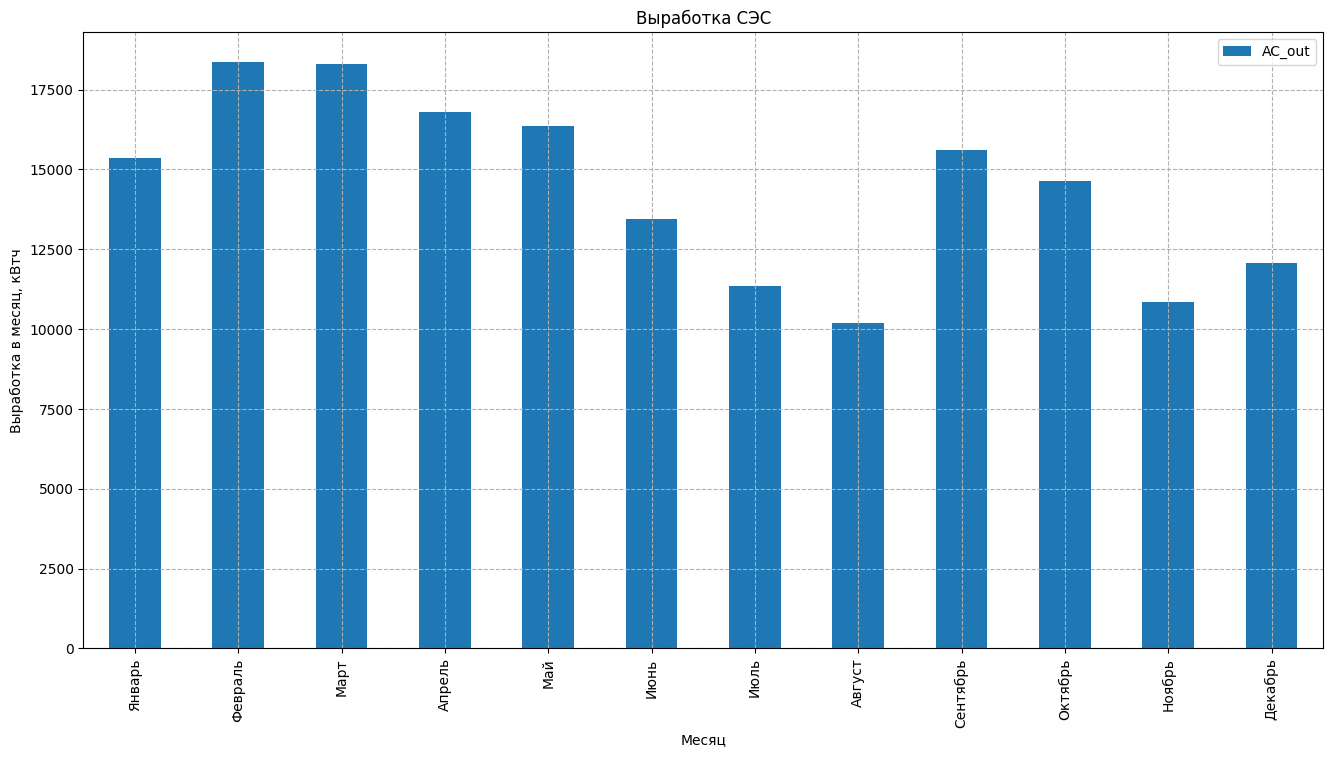

In [65]:
inverters_final = 10
series_final = Scheme_series_data.iloc[2,0]
parallel_final = Scheme_parallel_data.iloc[2,0]

AC_out_final = AC_out_1[2] * inverters_final
AC_out_final_months = [0.0] * 12
AC_out_final_data = pd.DataFrame(index = months_array, columns = ['AC_out'])

for i in range (lendata):
    month = int(PVGIS_data.index[i].to_pydatetime().strftime('%m'))
    AC_out_final_months[month - 1] += float(AC_out_final[i]) / 1000

AC_out_final_data['AC_out'] = AC_out_final_months
AC_out_final_data

AC_out_final_data.plot(figsize=(16,8), kind = 'bar')
plt.legend()
plt.grid(linestyle='--')
plt.ylabel('Выработка в месяц, кВтч')
plt.xlabel('Месяц')
plt.title('Выработка СЭС')
plt.show()



In [68]:
print(sum(AC_out_final_data['AC_out']))

173363.96539610508


In [51]:
GI_aoi_PVGIS = sum(pvlib.irradiance.poa_components(aoi = AOI_data['0'],
                                                 dni = PVGIS_data['poa_direct'],
                                                 poa_sky_diffuse = Perez_diffuse_sky_data['0'],
                                                 poa_ground_diffuse = Perez_diffuse_ground_data['0'])['poa_global'])
GI_aoi_SCS = sum(pvlib.irradiance.poa_components(aoi = AOI_data['0'],
                                                 dni = simple_clear_sky['dni'],
                                                 poa_sky_diffuse = Perez_diffuse_sky_data['0'],
                                                 poa_ground_diffuse = Perez_diffuse_ground_data['0'])['poa_global'])
k = GI_aoi_SCS / GI_aoi_PVGIS
k                        

0.6188054542732855